In [1]:
import importlib, subprocess, sys

# ── Install (torch/torchvision are NEVER touched — Colab's matched
#    preinstalled pair must stay intact or CUDA NMS silently breaks) ──
def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

_installed_now = []
if importlib.util.find_spec("ultralytics") is None:
    _pip("--no-deps", "ultralytics")          # --no-deps → torch stays untouched
    _installed_now.append("ultralytics")
for mod, pkg in {"lap": "lap>=0.5.12", "thop": "ultralytics-thop",
                 "yaml": "pyyaml", "psutil": "psutil", "requests": "requests",
                 "transformers": "transformers", "cv2": "opencv-python",
                 "sklearn": "scikit-learn", "matplotlib": "matplotlib",
                 "seaborn": "seaborn", "tqdm": "tqdm",
                 "pandas": "pandas", "scipy": "scipy"}.items():
    if importlib.util.find_spec(mod) is None:
        _pip(pkg); _installed_now.append(pkg)

if _installed_now:
    print("✅ Installed:", ", ".join(_installed_now))
    if any("lap" in p or "ultralytics" == p for p in _installed_now):
        print("⚠️ Runtime → Restart session, then re-run from this cell.")

import os, math, json, glob, random, shutil, time, warnings, zipfile, gc, logging
from collections import deque, defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from ultralytics import YOLO
from transformers import SwinForImageClassification
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split

logging.getLogger("ultralytics").setLevel(logging.ERROR)   # silence warning spam
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── CUDA NMS self-test (catches torch/torchvision mismatch early) ──
YOLO_DEVICE = "cpu"
if torch.cuda.is_available():
    try:
        import torchvision.ops as _ops
        _b = torch.rand(50, 4, device="cuda") * 100
        _ops.nms(_b, torch.rand(50, device="cuda"), 0.5)
        YOLO_DEVICE = 0
        print("✅ CUDA NMS OK — YOLO will run on GPU")
    except Exception as e:
        print("❌ CUDA NMS BROKEN (torch/torchvision mismatch):", e)
        print("   Fix: Runtime → Disconnect and delete runtime, then re-run.")
else:
    print("⚠️ No GPU — Runtime → Change runtime type → T4 GPU")

# ── Drive with auto-remount ──────────────────────────────────
from google.colab import drive

def ensure_drive():
    try:
        os.listdir("/content/drive/MyDrive")
        return
    except OSError:
        print("⚠️ Drive mount lost — remounting…")
        try:
            drive.flush_and_unmount()
        except Exception:
            pass
        drive.mount("/content/drive", force_remount=True)
        os.listdir("/content/drive/MyDrive")
        print("✅ Drive remounted")

drive.mount('/content/drive')
ensure_drive()


✅ Installed: ultralytics, lap>=0.5.12, ultralytics-thop
⚠️ Runtime → Restart session, then re-run from this cell.
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Device: cuda
GPU: Tesla T4
✅ CUDA NMS OK — YOLO will run on GPU
Mounted at /content/drive


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                  CONFIGURATION (v5 — MIL)                    ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Drive paths (NEW for v5 — old v4 files stay untouched) ───
DATASET_DIR  = "/content/drive/MyDrive/FYP-Dataset-AllahBad"
CROPS_ZIP    = "/content/drive/MyDrive/FYP-Crops32.zip"
DRIVE_CKPT   = "/content/drive/MyDrive/swin_mil_checkpoints"
BEST_PATH    = os.path.join(DRIVE_CKPT, "best_model_mil.pth")
LAST_PATH    = os.path.join(DRIVE_CKPT, "last_model_mil.pth")
HISTORY_PATH = os.path.join(DRIVE_CKPT, "train_history.json")
THRESH_PATH  = os.path.join(DRIVE_CKPT, "best_threshold.json")
SPLIT_PATH   = os.path.join(DRIVE_CKPT, "split.json")
STATUS_PATH  = os.path.join(DRIVE_CKPT, "pipeline_status.json")
METRICS_PATH = os.path.join(DRIVE_CKPT, "metrics.json")
os.makedirs(DRIVE_CKPT, exist_ok=True)

# ── Drive zip backups for every OTHER dataset variant this notebook
#    builds (framing ablation, cross-store) — everything gets a Drive
#    copy now, not just the main crops, so nothing rebuilds from scratch
#    after a Colab disconnect ────────────────────────────────
FULLFRAME_ZIP  = "/content/drive/MyDrive/FYP-FullFrame32.zip"
BGONLY_ZIP     = "/content/drive/MyDrive/FYP-BgOnly32.zip"
STORE2_ZIP     = "/content/drive/MyDrive/FYP-Store2-Crops32.zip"

def load_status():
    try:    return json.load(open(STATUS_PATH))
    except Exception: return {}

def set_status(key, value=True):
    s = load_status(); s[key] = value
    try:
        ensure_drive(); json.dump(s, open(STATUS_PATH, "w"), indent=2)
    except OSError:
        pass

print("Pipeline status:", load_status() or "(fresh start)")

# ── Local SSD paths (fast; wiped on runtime reset) ───────────
LOCAL_CROPS = "/content/FYP-Crops32"
LOCAL_TMP   = "/content/_tmp_video"
os.makedirs(LOCAL_CROPS, exist_ok=True)
os.makedirs(LOCAL_TMP, exist_ok=True)

# ── Data / model ─────────────────────────────────────────────
NUM_FRAMES   = 8      # model clip length (one MIL window)
TUBE_FRAMES  = 32     # frames stored per person tube  ← NEW in v5
IMG_SIZE     = 224
NUM_CLASSES  = 2
CLASSES      = ["Normal", "Shoplifting"]

# ── MIL training ─────────────────────────────────────────────
WINDOWS_PER_TUBE = 3   # random contiguous windows per tube (train)
VAL_WINDOWS      = 4   # evenly spaced windows (val/test)
BATCH_SIZE       = 4   # tubes per batch → 4×3×8 = 96 frames/step (T4-safe)
EPOCHS           = 30
LR               = 2e-5
WEIGHT_DECAY     = 1e-4
WARMUP_EPOCHS    = 3
PATIENCE         = 6
CKPT_EVERY       = 5
# (mixup removed in v5 — window sampling is the temporal augmentation)

# ── YOLO / tracking / crop building ──────────────────────────
YOLO_WEIGHTS        = "yolov8m.pt"
CONF_THRES          = 0.35
MIN_BOX_AREA        = 900
CROP_PAD            = 0.15
FRAME_STRIDE        = 1
MIN_TUBE_LENGTH     = 32     # person must be visible ≥ this many frames
MAX_CROPS_PER_TRACK = 96     # RAM cap per person (adaptive thinning)
MAIN_PERSON_ONLY    = True
ZIP_EVERY           = 25
FORCE_REBUILD       = False

# ── Inference / alerting (strict, v5) ────────────────────────
CLASSIFY_EVERY   = 4
BUFFER_SIZE      = 32
SMOOTH_WINDOW    = 9      # voting memory
VOTES_TO_FLAG    = 6      # ≥6 of last 9 votes → red
VOTES_TO_KEEP    = 4      # hysteresis: stay red while ≥4 of 9
MIN_FRAMES_SEEN  = 40     # watch a person ~1.5 s before judging
ALERT_MIN_THRES  = 0.70   # live threshold never goes below this
DEFAULT_THRES    = 0.75
COLOR_SHOPLIFT   = (0, 0, 255)
COLOR_NORMAL     = (0, 200, 0)
COLOR_ANALYZING  = (0, 200, 255)

def expand_box(x1, y1, x2, y2, W, H, pad=CROP_PAD):
    w, h = x2 - x1, y2 - y1
    x1 = max(0, int(x1 - w*pad)); y1 = max(0, int(y1 - h*pad))
    x2 = min(W, int(x2 + w*pad)); y2 = min(H, int(y2 + h*pad))
    return x1, y1, x2, y2


Pipeline status: {'crops_done': True, 'training_done': True, 'evaluation_done': True, 'framing_full_frame_done': True, 'framing_background_only_done': True}


In [3]:
def restore_dir_from_zip(local_dir, zip_path, pattern="*/*_id*", label="crops"):
    """Generic Drive -> local restore. Skips if local_dir already has content
    matching `pattern` (relative to local_dir), so it's a no-op on a warm runtime."""
    ensure_drive()
    if len(glob.glob(os.path.join(local_dir, pattern))) > 0:
        return
    if os.path.exists(zip_path):
        print(f"📥 Restoring {label} from Drive zip…")
        local_zip = "/content/_restore_tmp.zip"
        for attempt in range(3):
            try:
                shutil.copy(zip_path, local_zip)
                break
            except OSError:
                print("   Drive hiccup while restoring — retrying…")
                time.sleep(3); ensure_drive()
        with zipfile.ZipFile(local_zip) as z:
            z.extractall("/content")
        os.remove(local_zip)
        n = len(glob.glob(os.path.join(local_dir, pattern)))
        print(f"✅ Restored {n} items to {local_dir}")

def sync_dir_to_drive(local_dir, zip_path, label="crops"):
    """Generic local -> Drive backup. Zips local_dir and copies it to zip_path
    on Drive, retrying through Drive hiccups."""
    if not os.path.isdir(local_dir):
        return
    local_zip = "/content/_sync_tmp.zip"
    if os.path.exists(local_zip):
        os.remove(local_zip)
    base = shutil.make_archive(local_zip[:-4], "zip",
                               root_dir=os.path.dirname(local_dir),
                               base_dir=os.path.basename(local_dir))
    ensure_drive()
    for attempt in range(3):
        try:
            shutil.copy(base, zip_path)
            break
        except OSError:
            print("   Drive hiccup while syncing zip — retrying…")
            time.sleep(3); ensure_drive()
    print(f"   💾 Synced {label} zip → {zip_path} "
          f"({os.path.getsize(base)/1e6:.0f} MB)")
    os.remove(base)

def restore_crops_from_zip():
    restore_dir_from_zip(LOCAL_CROPS, CROPS_ZIP, pattern="*/*_id*", label="crops")

def sync_crops_to_drive():
    sync_dir_to_drive(LOCAL_CROPS, CROPS_ZIP, label="crops")

restore_crops_from_zip()

yolo_builder = YOLO(YOLO_WEIGHTS)

def reset_tracker(m):
    pred = getattr(m, "predictor", None)
    if pred is not None and getattr(pred, "trackers", None):
        for t in pred.trackers:
            t.reset()


class TrackBuffer:
    """RAM-bounded crop buffer: keeps ≤ MAX_CROPS_PER_TRACK small (224px)
    crops spread evenly over the person's whole appearance."""
    def __init__(self):
        self.crops, self.stride, self.seen = [], 1, 0
    def add(self, bgr_crop):
        if self.seen % self.stride == 0:
            self.crops.append(cv2.resize(bgr_crop, (IMG_SIZE, IMG_SIZE),
                                         interpolation=cv2.INTER_AREA))
            if len(self.crops) > MAX_CROPS_PER_TRACK:
                self.crops = self.crops[::2]
                self.stride *= 2
        self.seen += 1


@torch.no_grad()
def video_to_person_tubes(drive_video_path, out_root):
    """Track persons → save each tube as {video}_id{track}/0..31.jpg."""
    vid_id = os.path.splitext(os.path.basename(drive_video_path))[0]

    local_vid = os.path.join(LOCAL_TMP, os.path.basename(drive_video_path))
    for attempt in range(3):
        try:
            ensure_drive(); shutil.copy(drive_video_path, local_vid); break
        except OSError:
            time.sleep(3)
    else:
        return 0, False

    cap = cv2.VideoCapture(local_vid)
    if not cap.isOpened():
        os.remove(local_vid); return 0, False
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    reset_tracker(yolo_builder)
    tubes, fno = defaultdict(TrackBuffer), 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        fno += 1
        if FRAME_STRIDE > 1 and fno % FRAME_STRIDE:
            continue
        r = yolo_builder.track(frame, persist=True, classes=[0],
                               conf=CONF_THRES, tracker="bytetrack.yaml",
                               device=YOLO_DEVICE, verbose=False)[0]
        if r.boxes is None or r.boxes.id is None:
            continue
        for tid, (x1, y1, x2, y2) in zip(r.boxes.id.int().cpu().tolist(),
                                         r.boxes.xyxy.cpu().numpy()):
            if (x2-x1)*(y2-y1) < MIN_BOX_AREA:
                continue
            bx = expand_box(x1, y1, x2, y2, W, H)
            crop = frame[bx[1]:bx[3], bx[0]:bx[2]]
            if crop.size:
                tubes[tid].add(crop)
    cap.release()
    os.remove(local_vid)

    min_seen = max(TUBE_FRAMES, MIN_TUBE_LENGTH // FRAME_STRIDE)
    tubes = {t: b for t, b in tubes.items()
             if b.seen >= min_seen and len(b.crops) >= TUBE_FRAMES}
    if not tubes:
        gc.collect(); return 0, True
    if MAIN_PERSON_ONLY:
        best = max(tubes, key=lambda t: tubes[t].seen *
                   np.mean([c.shape[0]*c.shape[1] for c in tubes[t].crops]))
        tubes = {best: tubes[best]}

    saved = 0
    for tid, buf in tubes.items():
        idx = np.linspace(0, len(buf.crops)-1, TUBE_FRAMES).astype(int)
        d = os.path.join(out_root, f"{vid_id}_id{tid}")
        os.makedirs(d, exist_ok=True)
        for j, i in enumerate(idx):
            Image.fromarray(cv2.cvtColor(buf.crops[i], cv2.COLOR_BGR2RGB))\
                 .save(os.path.join(d, f"{j}.jpg"))
        saved += 1
    tubes.clear(); gc.collect()
    return saved, True


MANIFEST = os.path.join(LOCAL_CROPS, "processed.json")

def load_manifest():
    try:    return json.load(open(MANIFEST))
    except Exception: return {"done": [], "failed": []}

def save_manifest(m):
    json.dump(m, open(MANIFEST, "w"))

if load_status().get("crops_done") and not FORCE_REBUILD:
    print("⏭ Crop dataset already marked complete — skipping Section 3.")
else:
    manifest = load_manifest()
    done_set = set(manifest["done"])
    processed_since_sync = 0
    for cls in CLASSES:
        ensure_drive()
        src = os.path.join(DATASET_DIR, cls)
        dst = os.path.join(LOCAL_CROPS, cls)
        os.makedirs(dst, exist_ok=True)
        vids = sorted(glob.glob(os.path.join(src, "*.mp4")))
        todo = [v for v in vids if f"{cls}/{os.path.basename(v)}" not in done_set]
        print(f"\n📦 {cls}: {len(vids)} videos "
              f"({len(vids)-len(todo)} already done, {len(todo)} to go)")
        new, failed, no_person = 0, [], 0
        for vp in tqdm(todo, unit="video"):
            key = f"{cls}/{os.path.basename(vp)}"
            n, ok = video_to_person_tubes(vp, dst)
            if not ok:
                failed.append(os.path.basename(vp))
                manifest["failed"].append(key)
            else:
                if n == 0:
                    no_person += 1
                new += n
                manifest["done"].append(key); done_set.add(key)
            save_manifest(manifest)
            processed_since_sync += 1
            if processed_since_sync >= ZIP_EVERY:
                sync_crops_to_drive(); processed_since_sync = 0
        total = len(glob.glob(os.path.join(dst, "*_id*")))
        print(f"   ✅ {cls}: {new} new tubes | {total} total local")
        if no_person:
            print(f"   ℹ️ {no_person} videos had no person visible ≥{MIN_TUBE_LENGTH} frames")
        if failed:
            print(f"   ❌ {len(failed)} unreadable videos, e.g. {failed[:5]}")

    sync_crops_to_drive()
    all_vids = {f"{c}/{os.path.basename(v)}" for c in CLASSES
                for v in glob.glob(os.path.join(DATASET_DIR, c, "*.mp4"))}
    covered = set(manifest["done"]) | set(manifest["failed"])
    if all_vids <= covered:
        set_status("crops_done")
        print("\n✅ 32-frame crop dataset COMPLETE and backed up to Drive.")
    else:
        print(f"\n⏸ Partial: {len(all_vids - covered)} videos remain — "
              "re-run this cell to continue.")


📥 Restoring crops from Drive zip…
✅ Restored 814 items to /content/FYP-Crops32
⏭ Crop dataset already marked complete — skipping Section 3.


In [4]:

# ╔══════════════════════════════════════════════════════════════╗
# ║        AUTOMATIC TRACK / PERSON ANNOTATION (NO MANUAL CSV)  ║
# ╚══════════════════════════════════════════════════════════════╝
# This creates machine-generated annotations from YOLO + ByteTrack:
# video_id, class label (from dataset folder), track_id, frame number,
# bounding box, confidence, and visibility. These are pseudo-annotations,
# NOT human-verified ground truth for the identity of the shoplifter.
#
# Output:
#   DRIVE_CKPT/auto_person_annotations.csv
#   DRIVE_CKPT/auto_person_track_summary.csv
#
# The video-level Normal/Shoplifting label is inherited from the dataset
# folder. A track is NOT automatically declared to be the actual shoplifter.

AUTO_ANNOTATE = True
AUTO_ANNOTATE_OVERWRITE = False
AUTO_ANNOTATIONS_CSV = os.path.join(DRIVE_CKPT, "auto_person_annotations.csv")
AUTO_TRACK_SUMMARY_CSV = os.path.join(DRIVE_CKPT, "auto_person_track_summary.csv")

def _append_csv_rows(path, rows, columns):
    if not rows:
        return
    df = pd.DataFrame(rows, columns=columns)
    header = not os.path.exists(path)
    df.to_csv(path, mode="a", header=header, index=False)

def auto_annotate_video(video_path, class_name, model):
    """Track every person and emit frame-level machine annotations."""
    vid_id = os.path.splitext(os.path.basename(video_path))[0]
    local_vid = os.path.join(LOCAL_TMP, os.path.basename(video_path))
    for _ in range(3):
        try:
            ensure_drive()
            shutil.copy(video_path, local_vid)
            break
        except OSError:
            time.sleep(2)
    else:
        return [], []

    cap = cv2.VideoCapture(local_vid)
    if not cap.isOpened():
        if os.path.exists(local_vid): os.remove(local_vid)
        return [], []

    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    rows, track_stats = [], defaultdict(lambda: {
        "frames": 0, "conf_sum": 0.0, "area_sum": 0.0,
        "first_frame": None, "last_frame": None
    })

    reset_tracker(model)
    fno = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        fno += 1
        if FRAME_STRIDE > 1 and fno % FRAME_STRIDE:
            continue

        r = model.track(frame, persist=True, classes=[0], conf=CONF_THRES,
                        tracker="bytetrack.yaml", device=YOLO_DEVICE,
                        verbose=False)[0]
        if r.boxes is None or r.boxes.id is None:
            continue

        ids = r.boxes.id.int().cpu().tolist()
        boxes = r.boxes.xyxy.cpu().numpy()
        confs = (r.boxes.conf.cpu().numpy()
                 if r.boxes.conf is not None
                 else np.ones(len(ids), dtype=np.float32))

        for tid, box, conf in zip(ids, boxes, confs):
            x1, y1, x2, y2 = [int(v) for v in box]
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)
            area = max(0, x2-x1) * max(0, y2-y1)
            if area < MIN_BOX_AREA:
                continue

            st = track_stats[tid]
            st["frames"] += 1
            st["conf_sum"] += float(conf)
            st["area_sum"] += float(area)
            st["first_frame"] = fno if st["first_frame"] is None else st["first_frame"]
            st["last_frame"] = fno

            rows.append({
                "video_id": vid_id, "class_name": class_name,
                "class_id": CLASSES.index(class_name), "frame": fno,
                "track_id": int(tid), "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "confidence": float(conf), "box_area": int(area),
                "video_path": video_path
            })

    cap.release()
    if os.path.exists(local_vid): os.remove(local_vid)

    summaries = [{
        "video_id": vid_id, "class_name": class_name,
        "class_id": CLASSES.index(class_name), "track_id": int(tid),
        "frames_seen": st["frames"],
        "mean_confidence": st["conf_sum"] / max(1, st["frames"]),
        "mean_box_area": st["area_sum"] / max(1, st["frames"]),
        "first_frame": st["first_frame"], "last_frame": st["last_frame"],
        "eligible_tube": bool(st["frames"] >= MIN_TUBE_LENGTH)
    } for tid, st in track_stats.items()]
    return rows, summaries

if AUTO_ANNOTATE:
    ensure_drive()
    if AUTO_ANNOTATE_OVERWRITE:
        for p in [AUTO_ANNOTATIONS_CSV, AUTO_TRACK_SUMMARY_CSV]:
            if os.path.exists(p): os.remove(p)

    annotation_manifest = os.path.join(DRIVE_CKPT, "auto_annotation_manifest.json")
    try:
        ann_done = set(json.load(open(annotation_manifest)).get("done", []))
    except Exception:
        ann_done = set()

    ann_cols = ["video_id","class_name","class_id","frame","track_id",
                "x1","y1","x2","y2","confidence","box_area","video_path"]
    sum_cols = ["video_id","class_name","class_id","track_id","frames_seen",
                "mean_confidence","mean_box_area","first_frame","last_frame",
                "eligible_tube"]

    for class_name in CLASSES:
        src = os.path.join(DATASET_DIR, class_name)
        videos = sorted(glob.glob(os.path.join(src, "*.mp4")))
        for vp in tqdm(videos, desc=f"Auto-annotating {class_name}", unit="video"):
            key = f"{class_name}/{os.path.basename(vp)}"
            if key in ann_done:
                continue
            rows, summaries = auto_annotate_video(vp, class_name, yolo_builder)
            _append_csv_rows(AUTO_ANNOTATIONS_CSV, rows, ann_cols)
            _append_csv_rows(AUTO_TRACK_SUMMARY_CSV, summaries, sum_cols)
            ann_done.add(key)
            json.dump({"done": sorted(ann_done),
                       "timestamp": datetime.now().isoformat()},
                      open(annotation_manifest, "w"), indent=2)

    print(f"✅ Automatic annotations: {AUTO_ANNOTATIONS_CSV}")
    print(f"✅ Track summary: {AUTO_TRACK_SUMMARY_CSV}")
else:
    print("⏭ AUTO_ANNOTATE=False — skipped.")


Auto-annotating Shoplifting: 100%|██████████| 411/411 [00:00<00:00, 473067.77video/s]

✅ Automatic annotations: /content/drive/MyDrive/swin_mil_checkpoints/auto_person_annotations.csv
✅ Track summary: /content/drive/MyDrive/swin_mil_checkpoints/auto_person_track_summary.csv


In [5]:

# ╔══════════════════════════════════════════════════════════════╗
# ║          PERSON-TRACKED FRAMING ABLATION DATASETS           ║
# ╚══════════════════════════════════════════════════════════════╝
# Builds Full-frame and Background-only variants. Retraining is kept
# separate so the main proposed model is not overwritten.
#
# NEW: this used to write only to /content, so any Colab disconnect
# meant rebuilding the whole variant from video 0 — YOLO background
# removal on every frame is not cheap. Now each variant is:
#   • restored from its Drive zip at the start of the cell (instant
#     resume if a previous run already made progress)
#   • synced back to Drive every ZIP_EVERY videos, so at most a few
#     videos of work are ever lost to a disconnect
#   • marked complete in pipeline_status.json so a finished variant
#     is skipped entirely on the next run, instead of re-scanning
#     every video's frames on disk

RUN_FRAMING_BUILD = True
FULLFRAME_ROOT = "/content/FYP-FullFrame32"
BGONLY_ROOT = "/content/FYP-BgOnly32"

def _framing_complete(out_root, min_frac=0.9, verbose=False):
    """Real completeness check: every class must have at least min_frac of
    its source videos actually built (all TUBE_FRAMES saved). Replaces the
    old "does ANY file exist anywhere" check, which was satisfied by a
    partially-built dataset (e.g. Normal done, Shoplifting entirely
    missing) and caused the cell to falsely skip forever."""
    for cls in CLASSES:
        n_built = len(glob.glob(os.path.join(out_root, cls, "*", "0.jpg")))
        n_src = len(glob.glob(os.path.join(DATASET_DIR, cls, "*.mp4")))
        if verbose:
            print(f"   {cls}: {n_built}/{n_src} videos built")
        if n_src > 0 and n_built < n_src * min_frac:
            return False
    return True

def build_alt_crops(mode, out_root, zip_path, status_key):
    assert mode in {"full_frame", "background_only"}

    restore_dir_from_zip(out_root, zip_path, pattern="*/*/0.jpg", label=mode)
    complete = _framing_complete(out_root)

    if load_status().get(status_key) and not FORCE_REBUILD and complete:
        print(f"⏭ {mode} framing dataset already marked complete on Drive — skipping.")
        return
    if load_status().get(status_key) and not complete:
        # Status says done, but the actual per-class video counts don't back
        # that up — an earlier build/sync was interrupted or failed
        # silently, and a partially-built folder satisfied the old (too
        # loose) "any file exists" check. Don't trust the flag; show the
        # real per-class counts and resume the build for real. Per-video
        # frames already on disk are kept — only missing videos are redone.
        print(f"⚠️ {mode} was marked complete in pipeline_status.json, but "
              "the actual data is incomplete:")
        _framing_complete(out_root, verbose=True)
        print("   Resuming the build for real (existing videos are kept).")

    processed_since_sync = 0
    for cls in CLASSES:
        src = os.path.join(DATASET_DIR, cls)
        dst = os.path.join(out_root, cls)
        os.makedirs(dst, exist_ok=True)
        for vp in tqdm(sorted(glob.glob(os.path.join(src, "*.mp4"))),
                        desc=f"{cls}/{mode}", unit="video"):
            vid_name = os.path.splitext(os.path.basename(vp))[0]
            out_dir = os.path.join(dst, vid_name)
            if all(os.path.exists(os.path.join(out_dir, f"{j}.jpg"))
                   for j in range(TUBE_FRAMES)):
                continue
            local_vid = os.path.join(LOCAL_TMP, os.path.basename(vp))
            shutil.copy(vp, local_vid)
            cap = cv2.VideoCapture(local_vid)
            frames = []
            while len(frames) < TUBE_FRAMES:
                ok, f = cap.read()
                if not ok: break
                if mode == "background_only":
                    r = yolo_builder.predict(f, classes=[0], conf=CONF_THRES,
                                             device=YOLO_DEVICE, verbose=False)[0]
                    if r.boxes is not None:
                        for x1,y1,x2,y2 in r.boxes.xyxy.cpu().numpy().astype(int):
                            x1,y1 = max(0,x1),max(0,y1)
                            x2,y2 = min(f.shape[1],x2),min(f.shape[0],y2)
                            f[y1:y2, x1:x2] = 0
                frames.append(cv2.resize(f, (IMG_SIZE, IMG_SIZE)))
            cap.release()
            os.remove(local_vid)
            if len(frames) < TUBE_FRAMES:
                continue
            idx = np.linspace(0, len(frames)-1, TUBE_FRAMES).astype(int)
            os.makedirs(out_dir, exist_ok=True)
            for j,i in enumerate(idx):
                Image.fromarray(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB)).save(
                    os.path.join(out_dir, f"{j}.jpg"))
            processed_since_sync += 1
            if processed_since_sync >= ZIP_EVERY:
                sync_dir_to_drive(out_root, zip_path, label=mode)
                processed_since_sync = 0

    sync_dir_to_drive(out_root, zip_path, label=mode)
    if _framing_complete(out_root):
        set_status(status_key)
        print(f"✅ {mode} framing dataset COMPLETE and backed up to Drive.")
    else:
        print(f"⚠️ {mode} build pass finished but is still incomplete "
              "(some videos unreadable or skipped) — NOT marking as done. "
              "Re-run this cell to retry the missing ones:")
        _framing_complete(out_root, verbose=True)

if RUN_FRAMING_BUILD:
    build_alt_crops("full_frame", FULLFRAME_ROOT, FULLFRAME_ZIP, "framing_full_frame_done")
    build_alt_crops("background_only", BGONLY_ROOT, BGONLY_ZIP, "framing_background_only_done")
    print("✅ Framing ablation datasets built.")
else:
    print("⏭ Framing ablation build disabled.")


📥 Restoring full_frame from Drive zip…
✅ Restored 820 items to /content/FYP-FullFrame32
⏭ full_frame framing dataset already marked complete on Drive — skipping.
📥 Restoring background_only from Drive zip…
✅ Restored 820 items to /content/FYP-BgOnly32
⏭ background_only framing dataset already marked complete on Drive — skipping.
✅ Framing ablation datasets built.


In [9]:
restore_crops_from_zip()

def load_crop_dataset(root):
    dirs, labels = [], []
    for label, cls in enumerate(CLASSES):
        folder = os.path.join(root, cls)
        if not os.path.isdir(folder):
            print(f"⚠️  Missing folder: {folder}")
            continue
        for d in sorted(os.listdir(folder)):
            full = os.path.join(folder, d)
            if os.path.isdir(full) and \
               all(os.path.exists(os.path.join(full, f"{j}.jpg"))
                   for j in range(TUBE_FRAMES)):
                dirs.append(full)
                labels.append(label)
    return dirs, labels

LOCAL_SPLIT_PATH = os.path.join(LOCAL_CROPS, "split.json")

def save_split_to_drive(split_data):
    """Persist split.json inside the crop ZIP; Drive FUSE rejects JSON writes."""
    with open(LOCAL_SPLIT_PATH, "w") as f:
        json.dump(split_data, f, indent=2)
    sync_crops_to_drive()

all_dirs, all_labels = load_crop_dataset(LOCAL_CROPS)
print(f"Total 32-frame tubes: {len(all_dirs)} "
      f"(Normal: {all_labels.count(0)}, Shoplifting: {all_labels.count(1)})")
assert len(all_dirs) > 20, "Too few tubes — run Section 3 first (fully)!"

def rel(p):
    return os.path.relpath(p, LOCAL_CROPS)

def video_id_from_tube(path):
    return os.path.basename(path).rsplit("_id", 1)[0]

ensure_drive()
if os.path.exists(LOCAL_SPLIT_PATH):
    sp = json.load(open(LOCAL_SPLIT_PATH))
    known = {rel(d): l for d, l in zip(all_dirs, all_labels)}
    def restore(names):
        selected = [n for n in names if n in known]
        return ([os.path.join(LOCAL_CROPS, n) for n in selected],
                [known[n] for n in selected])
    X_train, y_train = restore(sp["train"])
    X_val, y_val = restore(sp["val"])
    X_test, y_test = restore(sp["test"])
    seen = set(sp["train"]) | set(sp["val"]) | set(sp["test"])
    new_dirs = [d for d in all_dirs if rel(d) not in seen]
    if new_dirs:
        X_train += new_dirs
        y_train += [known[rel(d)] for d in new_dirs]
        print(f"   ➕ {len(new_dirs)} new tubes added to TRAIN set")
    print("🔒 Loaded frozen video-level split from crop ZIP")
else:
    video_to_dirs = defaultdict(list)
    video_to_label = {}
    for d, label in zip(all_dirs, all_labels):
        video_id = video_id_from_tube(d)
        video_to_dirs[video_id].append(d)
        video_to_label[video_id] = label
    video_names = sorted(video_to_dirs)
    video_labels = [video_to_label[v] for v in video_names]
    train_v, test_v, train_l, test_l = train_test_split(
        video_names, video_labels, test_size=0.2, stratify=video_labels,
        random_state=SEED)
    train_v, val_v, train_l, val_l = train_test_split(
        train_v, train_l, test_size=0.125, stratify=train_l,
        random_state=SEED)
    def expand_video_split(names):
        dirs = [d for v in names for d in video_to_dirs[v]]
        labels = [video_to_label[v] for v in names for _ in video_to_dirs[v]]
        return dirs, labels
    X_train, y_train = expand_video_split(train_v)
    X_val, y_val = expand_video_split(val_v)
    X_test, y_test = expand_video_split(test_v)
    save_split_to_drive({"train": [rel(p) for p in X_train],
                         "val": [rel(p) for p in X_val],
                         "test": [rel(p) for p in X_test],
                         "split_unit": "source_video"})
    print("🔒 New video-level split created and frozen in crop ZIP")

print(f"Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

class MILTubeDataset(Dataset):
    """Returns (windows, label): windows is (K, T, C, H, W)."""
    def __init__(self, dirs, labels, train=False):
        self.dirs, self.labels, self.train = dirs, labels, train
        self.K = WINDOWS_PER_TUBE if train else VAL_WINDOWS
        self.norm = transforms.Normalize([0.485, 0.456, 0.406],
                                         [0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.dirs)

    def _load_frame(self, d, j, flip, b, c):
        img = Image.open(os.path.join(d, f"{j}.jpg")).convert("RGB")
        if flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if self.train:
            img = TF.adjust_brightness(img, b)
            img = TF.adjust_contrast(img, c)
        return self.norm(TF.to_tensor(img))

    def __getitem__(self, idx):
        d = self.dirs[idx]
        flip = self.train and random.random() < 0.5
        b = random.uniform(0.75, 1.25) if self.train else 1.0
        c = random.uniform(0.75, 1.25) if self.train else 1.0
        max_start = TUBE_FRAMES - NUM_FRAMES
        starts = ([random.randint(0, max_start) for _ in range(self.K)]
                  if self.train else
                  np.linspace(0, max_start, self.K).astype(int).tolist())
        needed = sorted({s + j for s in starts for j in range(NUM_FRAMES)})
        cache = {j: self._load_frame(d, j, flip, b, c) for j in needed}
        windows = torch.stack([torch.stack([cache[s + j]
                                            for j in range(NUM_FRAMES)])
                               for s in starts])
        return windows, self.labels[idx]

train_ds = MILTubeDataset(X_train, y_train, train=True)
val_ds = MILTubeDataset(X_val, y_val)
test_ds = MILTubeDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)
counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
class_weights = torch.tensor(counts.sum() / (NUM_CLASSES * counts),
                             dtype=torch.float32, device=device)
print("Class weights:", class_weights.cpu().numpy())

Total 32-frame tubes: 814 (Normal: 404, Shoplifting: 410)
   💾 Synced crops zip → /content/drive/MyDrive/FYP-Crops32.zip (259 MB)
🔒 New video-level split created and frozen in crop ZIP
Split → Train: 569 | Val: 82 | Test: 163
Class weights: [     1.0089     0.99129]


In [10]:
class TemporalSwin(nn.Module):
    def __init__(self, num_frames=NUM_FRAMES, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = SwinForImageClassification.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224",
            num_labels=num_classes, ignore_mismatched_sizes=True)
        hidden = self.backbone.config.hidden_size
        self.backbone.classifier = nn.Identity()
        self.pos_emb = nn.Embedding(num_frames, hidden)
        enc = nn.TransformerEncoderLayer(d_model=hidden, nhead=8,
                                         dim_feedforward=hidden*2, dropout=0.1,
                                         batch_first=True, norm_first=True)
        self.temporal_attn = nn.TransformerEncoder(enc, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, clip):                        # (B, T, C, H, W)
        B, T, C, H, W = clip.shape
        feats = self.backbone(pixel_values=clip.view(B*T, C, H, W)).logits
        feats = feats.view(B, T, -1)
        feats = feats + self.pos_emb(torch.arange(T, device=clip.device)).unsqueeze(0)
        feats = self.temporal_attn(feats).mean(dim=1)
        return self.classifier(self.dropout(feats))

model = TemporalSwin().to(device)
print(f"✅ TemporalSwin — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ TemporalSwin — 32.3M params


In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                              weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * p))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def safe_save(ckpt, drive_path):
    local = "/content/_ckpt_tmp.pth"
    torch.save(ckpt, local)
    for attempt in range(3):
        try:
            ensure_drive(); shutil.copy(local, drive_path); return
        except OSError:
            time.sleep(3)
    print("⚠️ Could not copy checkpoint to Drive — kept locally at", local)

def rng_snapshot():
    return {"py": random.getstate(), "np": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all()
                    if torch.cuda.is_available() else None}

def mil_forward(windows):
    """windows: (B, K, T, C, H, W) → per-tube shoplifting prob (B,)
    via max over the K window probabilities."""
    B, K, T, C, H, W = windows.shape
    logits = model(windows.view(B*K, T, C, H, W))          # (B*K, 2)
    p_win = torch.softmax(logits, dim=1)[:, 1].view(B, K)  # (B, K)
    return p_win.max(dim=1).values                          # (B,)

def run_epoch(loader, train, epoch=0):
    """Returns (loss, acc, preds, trues, probs) — probs = MIL max prob."""
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    probs_all, preds_all, true_all = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [{'Train' if train else 'Eval'}]",
                    leave=False)
        for windows, labels in pbar:
            windows = windows.to(device, non_blocking=True)
            labels = labels.to(device).float()
            p = mil_forward(windows).clamp(1e-5, 1 - 1e-5)
            w = class_weights[labels.long()]               # per-sample weight
            loss = F.binary_cross_entropy(p, labels, weight=w)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (p >= 0.5).long()
            total_loss += loss.item()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
            probs_all.extend(p.detach().cpu().numpy())
            preds_all.extend(preds.cpu().numpy())
            true_all.extend(labels.long().cpu().numpy())
            pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{correct/total:.3f}")
    return total_loss/len(loader), correct/total, preds_all, true_all, probs_all
# ── Resume (weights + optimizer + scheduler + RNG) ───────────
start_epoch, best_val_acc = 1, 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
ensure_drive()
if os.path.exists(LAST_PATH):
    ck = torch.load(LAST_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    optimizer.load_state_dict(ck["optimizer_state_dict"])
    scheduler.load_state_dict(ck["scheduler_state_dict"])
    start_epoch, best_val_acc = ck["epoch"] + 1, ck["best_val_acc"]
    if "rng" in ck:
        random.setstate(ck["rng"]["py"])
        np.random.set_state(ck["rng"]["np"])
        torch.set_rng_state(ck["rng"]["torch"].cpu())
        if torch.cuda.is_available() and ck["rng"].get("cuda") is not None:
            torch.cuda.set_rng_state_all([s.cpu() for s in ck["rng"]["cuda"]])
    print(f"🔄 Resumed at epoch {ck['epoch']} (best val_acc={best_val_acc:.4f})")
else:
    print("🆕 No checkpoint found — training from scratch (epoch 1)")
if os.path.exists(HISTORY_PATH):
    history = json.load(open(HISTORY_PATH))

no_improve = 0
for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc, *_ = run_epoch(train_loader, True, epoch)
    va_loss, va_acc, *_ = run_epoch(val_loader, False, epoch)
    scheduler.step()

    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
    try:
        ensure_drive(); json.dump(history, open(HISTORY_PATH, "w"))
    except OSError:
        pass
    print(f"Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} "
          f"| val {va_loss:.4f}/{va_acc:.4f} | lr {scheduler.get_last_lr()[0]:.2e}")

    ck = {"epoch": epoch, "model_state_dict": model.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "scheduler_state_dict": scheduler.state_dict(),
          "best_val_acc": max(best_val_acc, va_acc), "val_acc": va_acc,
          "rng": rng_snapshot()}
    safe_save(ck, LAST_PATH)
    if epoch % CKPT_EVERY == 0:
        safe_save(ck, os.path.join(DRIVE_CKPT, f"epoch_{epoch:02d}.pth"))
        print(f"   📸 Snapshot epoch_{epoch:02d}.pth saved")
    if va_acc > best_val_acc:
        best_val_acc, no_improve = va_acc, 0
        safe_save(ck, BEST_PATH)
        print(f"   💾 New best saved (val_acc={va_acc:.4f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"⏹ Early stopping at epoch {epoch}")
            break

set_status("training_done")
print(f"\n🏁 Training done. Best val_acc = {best_val_acc:.4f}")


🔄 Resumed at epoch 12 (best val_acc=0.9024)


Epoch 13 | train 0.3618/0.9385 | val 0.0836/0.9878 | lr 1.40e-05
   💾 New best saved (val_acc=0.9878)


Epoch 14 | train 0.2624/0.9543 | val 0.0245/0.9878 | lr 1.29e-05


Epoch 15 | train 0.2243/0.9596 | val 0.1731/0.9512 | lr 1.17e-05
   📸 Snapshot epoch_15.pth saved


Epoch 16 | train 0.1280/0.9736 | val 0.1824/0.9756 | lr 1.06e-05


Epoch 17 | train 0.1151/0.9807 | val 0.1465/0.9756 | lr 9.42e-06


Epoch 18 | train 0.1296/0.9754 | val 0.0824/0.9756 | lr 8.26e-06


Epoch 19 | train 0.0644/0.9842 | val 0.2067/0.9512 | lr 7.13e-06
⏹ Early stopping at epoch 19

🏁 Training done. Best val_acc = 0.9878


Loaded best model from epoch 13 (val_acc=0.9878)


💾 Saved raw test predictions for 163 tubes → /content/drive/MyDrive/swin_mil_checkpoints/test_raw_predictions.npz



🎯 TEST SET PERFORMANCE (MIL max-window, threshold 0.5)
✅ Test Accuracy : 93.25%
✅ Test Precision: 93.83%
✅ Test Recall   : 92.68%
✅ Test F1-Score : 93.25%
✅ Test Loss     : 0.4051

📊 OVERFITTING ANALYSIS — train 96.66% vs test 93.25% (gap 3.41%)
✅ GOOD - Acceptable overfitting

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal     0.9268    0.9383    0.9325        81
 Shoplifting     0.9383    0.9268    0.9325        82

    accuracy                         0.9325       163
   macro avg     0.9326    0.9326    0.9325       163
weighted avg     0.9326    0.9325    0.9325       163

      Class Precision Recall F1-Score  Support
     Normal    92.68% 93.83%   93.25%       81
Shoplifting    93.83% 92.68%   93.25%       82

📈 AUC-ROC: 0.9760


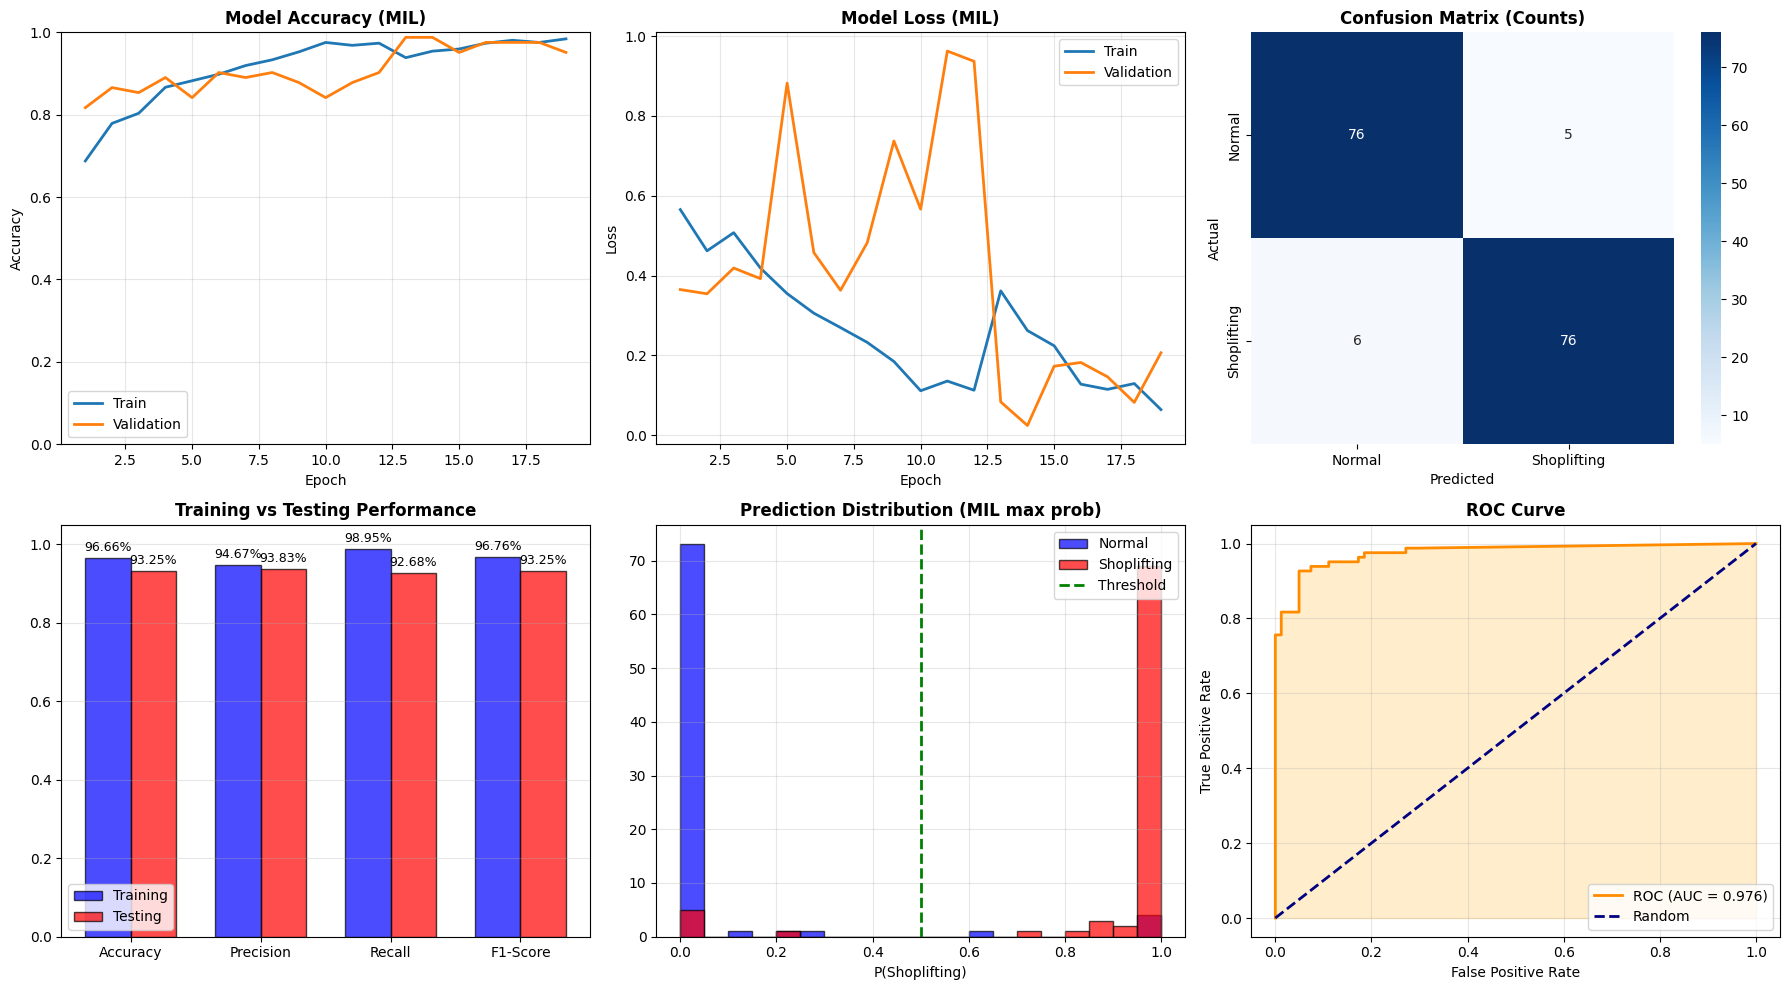


🔧 Best threshold (val F1): 0.30 (F1=0.9877) — saved.
   Test @ optimised threshold → acc 0.9325 | F1 0.9325

Threshold trade-off on TEST set:
  t=0.40 → catches 93% of thefts, false-alarms on 6% of normals
  t=0.50 → catches 93% of thefts, false-alarms on 6% of normals
  t=0.60 → catches 93% of thefts, false-alarms on 6% of normals
  t=0.70 → catches 93% of thefts, false-alarms on 5% of normals
  t=0.80 → catches 91% of thefts, false-alarms on 5% of normals

📋 FINAL SUMMARY — TemporalSwin MIL (YOLO person crops)
         Metric Training Testing
       Accuracy   96.66%  93.25%
      Precision   94.67%  93.83%
         Recall   98.95%  92.68%
       F1-Score   96.76%  93.25%
           Loss   0.1822  0.4051
        AUC-ROC        -   0.976
Overfitting Gap        -   3.41%

💾 metrics.json + plots saved to /content/drive/MyDrive/swin_mil_checkpoints


In [12]:
ensure_drive()
ckpt = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")

# ── Evaluate on TEST and (clean) TRAIN sets ──────────────────
te_loss, te_acc, preds, trues, probs = run_epoch(test_loader, False)
probs, trues, preds = np.array(probs), np.array(trues), np.array(preds)
# Raw per-tube predictions + parent video id for fair video-level evaluation
test_video_ids = np.array([os.path.basename(d).rsplit("_id", 1)[0] for d in X_test])
np.savez(os.path.join(DRIVE_CKPT, "test_raw_predictions.npz"),
         trues=trues, preds=preds, probs=probs, video_ids=test_video_ids)
print(f"💾 Saved raw test predictions for {len(test_video_ids)} tubes → "
      f"{os.path.join(DRIVE_CKPT, 'test_raw_predictions.npz')}")


train_eval_loader = DataLoader(MILTubeDataset(X_train, y_train, train=False),
                               batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)
tr_loss_e, tr_acc_e, tr_preds, tr_trues, _ = run_epoch(train_eval_loader, False)
tr_prec, tr_rec, tr_f1, _ = precision_recall_fscore_support(
    tr_trues, tr_preds, average="binary", zero_division=0)
test_prec, test_rec, test_f1_05, _ = precision_recall_fscore_support(
    trues, preds, average="binary", zero_division=0)

print("\n" + "="*70)
print("🎯 TEST SET PERFORMANCE (MIL max-window, threshold 0.5)")
print("="*70)
print(f"✅ Test Accuracy : {te_acc:.2%}")
print(f"✅ Test Precision: {test_prec:.2%}")
print(f"✅ Test Recall   : {test_rec:.2%}")
print(f"✅ Test F1-Score : {test_f1_05:.2%}")
print(f"✅ Test Loss     : {te_loss:.4f}")

gap = tr_acc_e - te_acc
print(f"\n📊 OVERFITTING ANALYSIS — train {tr_acc_e:.2%} vs test {te_acc:.2%} "
      f"(gap {gap:.2%})")
if gap < 0.03:   print("✅ EXCELLENT - Minimal overfitting!")
elif gap < 0.06: print("✅ GOOD - Acceptable overfitting")
elif gap < 0.10: print("⚠️ MODERATE - Still some overfitting")
else:            print("⚠️ HIGH - More regularization / data needed")

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(trues, preds, target_names=CLASSES, digits=4))

precision_c, recall_c, f1_c, support_c = precision_recall_fscore_support(
    trues, preds, average=None, zero_division=0)
print(pd.DataFrame({"Class": CLASSES,
                    "Precision": [f"{p:.2%}" for p in precision_c],
                    "Recall":    [f"{r:.2%}" for r in recall_c],
                    "F1-Score":  [f"{f:.2%}" for f in f1_c],
                    "Support":   support_c}).to_string(index=False))

cm = confusion_matrix(trues, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
fpr, tpr, _ = roc_curve(trues, probs)
roc_auc = auc(fpr, tpr)
print(f"\n📈 AUC-ROC: {roc_auc:.4f}")

# ═══ 2×3 plot grid ═══
hist_epochs = range(1, len(history["train_acc"]) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].plot(hist_epochs, history["train_acc"], label="Train", linewidth=2)
axes[0, 0].plot(hist_epochs, history["val_acc"], label="Validation", linewidth=2)
axes[0, 0].set_title("Model Accuracy (MIL)", fontweight="bold")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3); axes[0, 0].set_ylim([0, 1])

axes[0, 1].plot(hist_epochs, history["train_loss"], label="Train", linewidth=2)
axes[0, 1].plot(hist_epochs, history["val_loss"], label="Validation", linewidth=2)
axes[0, 1].set_title("Model Loss (MIL)", fontweight="bold")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0, 2])
axes[0, 2].set_title("Confusion Matrix (Counts)", fontweight="bold")
axes[0, 2].set_xlabel("Predicted"); axes[0, 2].set_ylabel("Actual")

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
train_vals = [tr_acc_e, tr_prec, tr_rec, tr_f1]
test_vals  = [te_acc, test_prec, test_rec, test_f1_05]
x = np.arange(4); width = 0.35
b1 = axes[1, 0].bar(x - width/2, train_vals, width, label="Training",
                    alpha=0.7, color="blue", edgecolor="black")
b2 = axes[1, 0].bar(x + width/2, test_vals, width, label="Testing",
                    alpha=0.7, color="red", edgecolor="black")
axes[1, 0].set_title("Training vs Testing Performance", fontweight="bold")
axes[1, 0].set_ylim(0, 1.05); axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metric_names); axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis="y")
for bars, vals in [(b1, train_vals), (b2, test_vals)]:
    for bar, v in zip(bars, vals):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{v:.2%}", ha="center", va="bottom", fontsize=9)

axes[1, 1].hist(probs[trues == 0], alpha=0.7, label="Normal", bins=20,
                color="blue", edgecolor="black")
axes[1, 1].hist(probs[trues == 1], alpha=0.7, label="Shoplifting", bins=20,
                color="red", edgecolor="black")
axes[1, 1].axvline(x=0.5, color="green", linestyle="--", linewidth=2,
                   label="Threshold")
axes[1, 1].set_title("Prediction Distribution (MIL max prob)", fontweight="bold")
axes[1, 1].set_xlabel("P(Shoplifting)"); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

axes[1, 2].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1, 2].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
axes[1, 2].fill_between(fpr, tpr, alpha=0.2, color="orange")
axes[1, 2].set_xlabel("False Positive Rate"); axes[1, 2].set_ylabel("True Positive Rate")
axes[1, 2].set_title("ROC Curve", fontweight="bold")
axes[1, 2].legend(loc="lower right"); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_CKPT, "MIL_evaluation_plots.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# ── Threshold optimised on VALIDATION ────────────────────────
_, _, _, v_true, v_prob = run_epoch(val_loader, False)
v_true, v_prob = np.array(v_true), np.array(v_prob)
best_t, best_f1v = 0.5, 0
for t in np.arange(0.30, 0.90, 0.01):
    f1 = f1_score(v_true, (v_prob >= t).astype(int))
    if f1 > best_f1v:
        best_f1v, best_t = f1, t
json.dump({"threshold": float(best_t)}, open(THRESH_PATH, "w"))
test_f1_t = f1_score(trues, (probs >= best_t).astype(int))
test_acc_t = ((probs >= best_t).astype(int) == trues).mean()
print(f"\n🔧 Best threshold (val F1): {best_t:.2f} (F1={best_f1v:.4f}) — saved.")
print(f"   Test @ optimised threshold → acc {test_acc_t:.4f} | F1 {test_f1_t:.4f}")

print("\nThreshold trade-off on TEST set:")
for t in [0.40, 0.50, 0.60, 0.70, 0.80]:
    p = (probs >= t).astype(int)
    rec  = (p[trues == 1] == 1).mean()
    fpr_ = (p[trues == 0] == 1).mean()
    print(f"  t={t:.2f} → catches {rec:.0%} of thefts, "
          f"false-alarms on {fpr_:.0%} of normals")

# ── Summary + JSON export ────────────────────────────────────
print("\n" + "="*70)
print("📋 FINAL SUMMARY — TemporalSwin MIL (YOLO person crops)")
print("="*70)
print(pd.DataFrame({
    "Metric":   ["Accuracy", "Precision", "Recall", "F1-Score",
                 "Loss", "AUC-ROC", "Overfitting Gap"],
    "Training": [f"{tr_acc_e:.2%}", f"{tr_prec:.2%}", f"{tr_rec:.2%}",
                 f"{tr_f1:.2%}", f"{tr_loss_e:.4f}", "-", "-"],
    "Testing":  [f"{te_acc:.2%}", f"{test_prec:.2%}", f"{test_rec:.2%}",
                 f"{test_f1_05:.2%}", f"{te_loss:.4f}", f"{roc_auc:.3f}",
                 f"{gap:.2%}"]}).to_string(index=False))

json.dump({
    "model_name": "TemporalSwin_MIL_YOLO_PersonCrops",
    "architecture": {
        "backbone": "Swin-Tiny", "temporal": "1-layer Transformer",
        "mil": f"max over windows | tube={TUBE_FRAMES}f, window={NUM_FRAMES}f, "
               f"K_train={WINDOWS_PER_TUBE}, K_eval={VAL_WINDOWS}",
        "detection": "YOLOv8m + ByteTrack", "batch_size": BATCH_SIZE,
        "best_epoch": int(ckpt["epoch"])},
    "test_accuracy": float(te_acc), "test_precision": float(test_prec),
    "test_recall": float(test_rec), "test_f1": float(test_f1_05),
    "test_loss": float(te_loss), "train_accuracy": float(tr_acc_e),
    "overfitting_gap": float(gap), "auc_roc": float(roc_auc),
    "threshold": float(best_t),          # ← read by comparison_models notebook's THRESH_REGISTRY
    "optimised_threshold": float(best_t),  # kept for backward compatibility
    "test_acc_at_threshold": float(test_acc_t),
    "test_f1_at_threshold": float(test_f1_t),
    "confusion_matrix": cm.tolist(),
    "confusion_matrix_percentages": cm_pct.tolist(),
    "classification_report": classification_report(
        trues, preds, target_names=CLASSES, output_dict=True),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    open(METRICS_PATH, "w"), indent=2)
set_status("evaluation_done")
print(f"\n💾 metrics.json + plots saved to {DRIVE_CKPT}")


In [13]:
import copy

# ╔══════════════════════════════════════════════════════════════╗
# ║        WINDOW-COUNT + MIL-POOLING ABLATION (OPTIONAL)       ║
# ╚══════════════════════════════════════════════════════════════╝
# The guide recommends K=[1,2,3,4,6] and max/mean/attention pooling.
# Disabled by default because these are full retraining experiments.
#
# Resumable via Drive at two levels —
#   1. Variant-level: each variant's best weights land in
#      ABLATION_DIR/model_K{K}.pth or model_pool_{mode}.pth, and its
#      row is appended to the results CSV as soon as it finishes (not
#      just at the very end of the whole sweep). Re-running the cell
#      skips any variant whose model file is already on Drive.
#   2. Epoch-level: while a variant is training, its progress
#      (weights, optimizer state, best-so-far state, patience counter,
#      current safe batch size) is checkpointed to Drive after every
#      epoch. If the runtime dies mid-variant, re-running the cell
#      resumes that variant from its last completed epoch.
#
# OOM FIX: a forward pass here processes BATCH_SIZE * K * NUM_FRAMES
# images at once (K windows per tube, unlike normal training which is
# fixed at WINDOWS_PER_TUBE=3). K=6 is 2x the frames of K=3, which is
# what was blowing past GPU memory. Two mitigations:
#   • batch size is now scaled down automatically for K > 3, so total
#     frames-per-step stays close to what already fits comfortably
#   • training runs under autocast (mixed precision) + GradScaler,
#     roughly halving activation memory
# and as a last-resort safety net, if a CUDA OOM still happens mid-epoch,
# it's caught, the cache is cleared, the batch size is halved, and the
# SAME epoch is retried automatically (the reduced batch size is also
# saved into the resume checkpoint, so a later re-run won't repeat the
# same OOM).

# ── Clear any GPU memory stuck from a previous crashed run in THIS
#    session before we start. A cell that dies mid-exception keeps
#    sys.last_traceback alive in Jupyter, which pins every local
#    variable (including GPU tensors) from the failed stack frames —
#    so a crash can leave the GPU "full" even with nothing running. ──
import sys
for _attr in ("last_traceback", "last_value", "last_type"):
    if hasattr(sys, _attr):
        setattr(sys, _attr, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory before sweep — allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB, "
          f"reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

RUN_WINDOW_ABLATION = True
RUN_POOLING_ABLATION = True
ABLATION_EPOCHS = EPOCHS
ABLATION_DIR = os.path.join(DRIVE_CKPT, "ablations")
os.makedirs(ABLATION_DIR, exist_ok=True)

def batch_size_for_K(K):
    """Keep total frames-per-step (batch * K * NUM_FRAMES) close to the
    BATCH_SIZE=4, K=3 configuration the main model was already tuned for."""
    if K <= 3:
        return BATCH_SIZE
    return max(1, (BATCH_SIZE * 3) // K)

def mil_pool_variant(p_win, mode="max"):
    if mode == "max":
        return p_win.max(dim=1).values
    if mode == "mean":
        return p_win.mean(dim=1)
    if mode == "attn":
        # Score-based, parameter-free attention over window probabilities.
        w = torch.softmax(p_win, dim=1)
        return (w * p_win).sum(dim=1)
    raise ValueError(f"Unknown pooling mode: {mode}")

def run_epoch_variant(loader, model_obj, optimizer_obj=None, pool_mode="max",
                      epoch=0, scaler=None):
    train = optimizer_obj is not None
    model_obj.train() if train else model_obj.eval()
    total_loss = correct = total = 0
    probs_all, preds_all, true_all = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for windows, labels in tqdm(loader, desc=f"ABL {pool_mode} {epoch:02d}",
                                    leave=False):
            windows = windows.to(device, non_blocking=True)
            labels = labels.to(device).float()
            B, K, T, C, H, W = windows.shape
            # Only the backbone forward pass runs under autocast — softmax/
            # pooling/BCE stay in fp32. binary_cross_entropy (unlike
            # binary_cross_entropy_with_logits) is explicitly unsafe under
            # autocast and PyTorch will raise a RuntimeError if it's included.
            with torch.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model_obj(windows.view(B*K, T, C, H, W))
            logits = logits.float()
            p_win = torch.softmax(logits, dim=1)[:,1].view(B,K)
            p = mil_pool_variant(p_win, pool_mode).clamp(1e-5, 1-1e-5)
            loss = F.binary_cross_entropy(p, labels,
                                         weight=class_weights[labels.long()])
            if train:
                optimizer_obj.zero_grad()
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer_obj)
                    nn.utils.clip_grad_norm_(model_obj.parameters(), 1.0)
                    scaler.step(optimizer_obj)
                    scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model_obj.parameters(), 1.0)
                    optimizer_obj.step()
            pred = (p >= 0.5).long()
            total_loss += loss.item()
            correct += (pred == labels.long()).sum().item()
            total += labels.numel()
            probs_all.extend(p.detach().float().cpu().numpy())
            preds_all.extend(pred.cpu().numpy())
            true_all.extend(labels.long().cpu().numpy())
    return total_loss/max(1,len(loader)), correct/max(1,total), preds_all, true_all, probs_all

def _load_ablation_results(path):
    if os.path.exists(path):
        try:    return pd.read_csv(path).to_dict("records")
        except Exception: return []
    return []

def _save_ablation_results(path, rows):
    ensure_drive()
    for attempt in range(3):
        try:
            pd.DataFrame(rows).to_csv(path, index=False)
            return
        except OSError:
            print("   Drive hiccup while saving results — retrying…")
            time.sleep(3); ensure_drive()

def _save_resume_ckpt(path, payload):
    local = "/content/_ablation_resume_tmp.pth"
    torch.save(payload, local)
    for attempt in range(3):
        try:
            ensure_drive(); shutil.copy(local, path); break
        except OSError:
            print("   Drive hiccup while checkpointing — retrying…")
            time.sleep(3)
    os.remove(local)

def _free_gpu_mem(*objs):
    for o in objs:
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def run_ablation_variant(tag, pool_mode, train_ds_v, val_loader_v, test_loader_v,
                         final_model_path, init_batch_size):
    """Trains ONE ablation variant with Drive resume at both the variant
    and epoch level, and OOM-safe batch-size backoff. Returns
    (accuracy, precision, recall, f1)."""
    resume_path = os.path.join(ABLATION_DIR, f"resume_{tag}.pth")

    if os.path.exists(final_model_path):
        print(f"⏭ {tag}: final model already on Drive — reusing (no retraining).")
        model_v = TemporalSwin().to(device)
        model_v.load_state_dict(torch.load(final_model_path, map_location=device))
        if os.path.exists(resume_path):
            os.remove(resume_path)
    else:
        model_v = TemporalSwin().to(device)
        opt_v = torch.optim.AdamW(model_v.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
        start_epoch, best_val_acc_v, best_state_v, patience_ctr = 1, -1.0, None, 0
        bs_v = init_batch_size

        if os.path.exists(resume_path):
            ck = torch.load(resume_path, map_location=device, weights_only=False)
            model_v.load_state_dict(ck["model_state"])
            opt_v.load_state_dict(ck["opt_state"])
            start_epoch    = ck["epoch"] + 1
            best_val_acc_v = ck["best_val_acc"]
            best_state_v   = ck["best_state"]
            patience_ctr   = ck["patience_ctr"]
            bs_v           = ck.get("batch_size", init_batch_size)
            print(f"🔄 {tag}: resuming from epoch {start_epoch} "
                 f"(best val_acc so far={best_val_acc_v:.4f}, batch_size={bs_v})")

        def make_loader(bs):
            return DataLoader(train_ds_v, batch_size=bs, shuffle=True,
                              num_workers=2, pin_memory=True)
        train_loader_v = make_loader(bs_v)

        # Early stopping (same PATIENCE as main training) — without this, every
        # variant blindly ran all ABLATION_EPOCHS (30) instead of stopping once
        # converged (main model only needed 12), which is why this was taking
        # ~2.5x longer per variant than necessary across all 8 variants.
        epoch = start_epoch
        while epoch <= ABLATION_EPOCHS:
            try:
                run_epoch_variant(train_loader_v, model_v, opt_v, pool_mode, epoch, scaler)
                _, val_acc_v, *_ = run_epoch_variant(val_loader_v, model_v, None, pool_mode, epoch)
            except torch.cuda.OutOfMemoryError:
                _free_gpu_mem()
                new_bs = max(1, bs_v // 2)
                if new_bs == bs_v:
                    print(f"❌ {tag}: OOM at batch_size=1 — cannot reduce further. "
                         "Consider lowering NUM_FRAMES or IMG_SIZE.")
                    raise
                print(f"⚠️ {tag}: CUDA OOM at epoch {epoch}, batch_size={bs_v} — "
                     f"clearing cache and retrying at batch_size={new_bs}.")
                bs_v = new_bs
                train_loader_v = make_loader(bs_v)
                _save_resume_ckpt(resume_path, {
                    "epoch": epoch - 1, "model_state": model_v.state_dict(),
                    "opt_state": opt_v.state_dict(), "best_val_acc": best_val_acc_v,
                    "best_state": best_state_v, "patience_ctr": patience_ctr,
                    "batch_size": bs_v,
                })
                continue   # retry the SAME epoch at the smaller batch size

            if val_acc_v > best_val_acc_v:
                best_val_acc_v, patience_ctr = val_acc_v, 0
                best_state_v = copy.deepcopy(model_v.state_dict())
            else:
                patience_ctr += 1

            # Checkpoint after EVERY epoch so a disconnect never costs more
            # than one epoch of this variant's progress.
            _save_resume_ckpt(resume_path, {
                "epoch": epoch, "model_state": model_v.state_dict(),
                "opt_state": opt_v.state_dict(), "best_val_acc": best_val_acc_v,
                "best_state": best_state_v, "patience_ctr": patience_ctr,
                "batch_size": bs_v,
            })

            if patience_ctr >= PATIENCE:
                print(f"⏹ {tag}: early stopping at epoch {epoch} (best val_acc={best_val_acc_v:.4f})")
                break
            epoch += 1

        model_v.load_state_dict(best_state_v)   # evaluate the BEST epoch, not the last one
        ensure_drive()
        torch.save(best_state_v, final_model_path)
        if os.path.exists(resume_path):
            os.remove(resume_path)   # variant done — drop the epoch-level resume file
        _free_gpu_mem(opt_v, scaler, train_loader_v)

    _, te_acc_v, te_p_v, te_t_v, te_prob_v = run_epoch_variant(
        test_loader_v, model_v, None, pool_mode)
    p_v, r_v, f1_v, _ = precision_recall_fscore_support(
        te_t_v, te_p_v, average="binary", zero_division=0)
    _free_gpu_mem(model_v)   # clear this variant's weights before the next one starts
    return te_acc_v, p_v, r_v, f1_v

if RUN_WINDOW_ABLATION:
    _ORIGINAL_WINDOWS_PER_TUBE = WINDOWS_PER_TUBE   # restore after the sweep — otherwise
                                                     # a later re-run of the main training
                                                     # cell silently trains at K=6, not K=3
    window_csv = os.path.join(ABLATION_DIR, "window_results.csv")
    window_results = _load_ablation_results(window_csv)
    done_Ks = {int(r["K"]) for r in window_results}
    for K in [1, 2, 3, 4, 6]:
        if K in done_Ks:
            print(f"⏭ K={K}: already in {window_csv} — skipping.")
            continue
        WINDOWS_PER_TUBE = K
        train_ds_k = MILTubeDataset(X_train, y_train, train=True)
        model_path_k = os.path.join(ABLATION_DIR, f"model_K{K}.pth")
        bs_k = batch_size_for_K(K)
        print(f"▶ K={K}: batch_size={bs_k} ({bs_k*K*NUM_FRAMES} frames/step)")
        te_acc_k, p_k, r_k, f1_k = run_ablation_variant(
            f"K{K}", "max", train_ds_k, val_loader, test_loader, model_path_k, bs_k)
        window_results.append({"K":K, "accuracy":te_acc_k,
                               "precision":p_k, "recall":r_k, "f1":f1_k})
        _save_ablation_results(window_csv, window_results)   # persisted immediately,
                                                              # not just at sweep end
    display(pd.DataFrame(window_results))
    WINDOWS_PER_TUBE = _ORIGINAL_WINDOWS_PER_TUBE   # restore — see note above
    print(f"🔒 WINDOWS_PER_TUBE restored to {WINDOWS_PER_TUBE} after ablation sweep")
else:
    print("⏭ Window-count ablation disabled.")

if RUN_POOLING_ABLATION:
    pooling_csv = os.path.join(ABLATION_DIR, "pooling_results.csv")
    pooling_results = _load_ablation_results(pooling_csv)
    done_modes = {r["pooling"] for r in pooling_results}
    WINDOWS_PER_TUBE = 3
    train_ds_p = MILTubeDataset(X_train, y_train, train=True)
    for mode in ["max", "mean", "attn"]:
        if mode in done_modes:
            print(f"⏭ pooling={mode}: already in {pooling_csv} — skipping.")
            continue
        model_path_p = os.path.join(ABLATION_DIR, f"model_pool_{mode}.pth")
        te_acc_p, pp, rr, ff = run_ablation_variant(
            f"pool_{mode}", mode, train_ds_p, val_loader, test_loader,
            model_path_p, BATCH_SIZE)
        pooling_results.append({"pooling":mode, "accuracy":te_acc_p,
                                "precision":pp, "recall":rr, "f1":ff})
        _save_ablation_results(pooling_csv, pooling_results)
    display(pd.DataFrame(pooling_results))
else:
    print("⏭ MIL pooling ablation disabled.")


GPU memory before sweep — allocated: 0.99 GB, reserved: 1.36 GB
⏭ K=1: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/window_results.csv — skipping.
⏭ K=2: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/window_results.csv — skipping.
⏭ K=3: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/window_results.csv — skipping.
⏭ K=4: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/window_results.csv — skipping.
⏭ K=6: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/window_results.csv — skipping.


,K,accuracy,precision,recall,f1
0,1,0.827160,0.781250,0.914634,0.842697
1,2,0.808642,0.793103,0.841463,0.816568
2,3,0.827160,0.864865,0.780488,0.820513
3,4,0.845679,0.820225,0.890244,0.853801
4,6,0.870370,0.850575,0.902439,0.875740


🔒 WINDOWS_PER_TUBE restored to 3 after ablation sweep
⏭ pooling=max: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/pooling_results.csv — skipping.
⏭ pooling=mean: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/pooling_results.csv — skipping.
⏭ pooling=attn: already in /content/drive/MyDrive/swin_mil_checkpoints/ablations/pooling_results.csv — skipping.


,pooling,accuracy,precision,recall,f1
0,max,0.839506,0.804348,0.902439,0.850575
1,mean,0.864198,0.857143,0.878049,0.867470
2,attn,0.858025,0.810526,0.939024,0.870056


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║     PERSON-CROP vs FULL-FRAME vs BACKGROUND-ONLY EVALUATION  ║
# ╚══════════════════════════════════════════════════════════════╝
# Directly answers the supervisor's ask: quantitatively demonstrate that
# person-tracked cropping helps, rather than just asserting it.
#
# Trains the SAME config as the deployed model (K=3 windows, max pooling)
# on three input representations:
#   • person_crop      — your main model's actual input (LOCAL_CROPS)
#   • full_frame        — same videos, uncropped whole frames (built in cell 4)
#   • background_only    — same videos, person pixels zeroed out (cell 4)
#
# Fairness: full_frame / background_only are restricted to the EXACT same
# train/val/test VIDEO split as person_crop (derived from split.json), so
# this is a like-for-like comparison on identical videos, not just three
# differently-sized datasets. Uses the same run_ablation_variant() machinery
# as the K/pooling sweep above, so it's resumable at both the variant level
# (skip if model already on Drive) and the epoch level (Drive checkpoint
# every epoch) — a disconnect never costs more than one epoch.

RUN_FRAMING_EVAL = True
FRAMING_DIR = os.path.join(DRIVE_CKPT, "framing_eval")
os.makedirs(FRAMING_DIR, exist_ok=True)

def video_id_of(path):
    return os.path.basename(path).rsplit("_id", 1)[0]

def framing_video_split():
    return ({video_id_of(d) for d in X_train},
            {video_id_of(d) for d in X_val},
            {video_id_of(d) for d in X_test})

def framing_split_dirs(framing_root):
    """Map the person-crop model's frozen video split onto a framing
    dataset (full-frame / background-only), so all three input types are
    evaluated on IDENTICAL videos — not different subsets."""
    train_vids, val_vids, test_vids = framing_video_split()
    dirs, labels = load_crop_dataset(framing_root)
    def pick(vidset):
        d2 = [d for d in dirs if os.path.basename(d) in vidset]
        l2 = [l for d, l in zip(dirs, labels) if os.path.basename(d) in vidset]
        return d2, l2
    return pick(train_vids), pick(val_vids), pick(test_vids)

def run_framing_variant(tag, root, model_path):
    (tr_d, tr_l), (va_d, va_l), (te_d, te_l) = framing_split_dirs(root)
    print(f"{tag}: matched train={len(tr_d)} val={len(va_d)} test={len(te_d)} "
          f"videos (person-crop split: train={len(X_train)} val={len(X_val)} "
          f"test={len(X_test)})")
    if len(tr_d) < 10 or len(te_d) < 5:
        print(f"⚠️ {tag}: too few matched videos — skipping. This means cell 4 "
              "(framing dataset build) hasn't finished for this variant, or "
              "very few videos overlap with the frozen split. Re-run cell 4 "
              "to completion first.")
        return None
    tr_ds = MILTubeDataset(tr_d, tr_l, train=True)
    va_loader = DataLoader(MILTubeDataset(va_d, va_l, train=False),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te_loader = DataLoader(MILTubeDataset(te_d, te_l, train=False),
                           batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    acc, prec, rec, f1 = run_ablation_variant(
        tag, "max", tr_ds, va_loader, te_loader, model_path, BATCH_SIZE)
    return {"input": tag, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "n_test": len(te_d)}

if RUN_FRAMING_EVAL:
    framing_csv = os.path.join(FRAMING_DIR, "framing_results.csv")
    framing_results = _load_ablation_results(framing_csv)
    done_inputs = {r["input"] for r in framing_results}

    # person_crop row reuses the already-trained main model's actual test
    # numbers from cell 8 — no need to retrain what you already have.
    if "person_crop" not in done_inputs:
        framing_results.append({"input": "person_crop", "accuracy": te_acc,
                                "precision": test_prec, "recall": test_rec,
                                "f1": test_f1_05, "n_test": len(X_test)})
        _save_ablation_results(framing_csv, framing_results)
        done_inputs.add("person_crop")

    variants = [("full_frame", FULLFRAME_ROOT,
                os.path.join(FRAMING_DIR, "model_full_frame.pth")),
               ("background_only", BGONLY_ROOT,
                os.path.join(FRAMING_DIR, "model_background_only.pth"))]
    for tag, root, path in variants:
        if tag in done_inputs:
            print(f"⏭ {tag}: already in {framing_csv} — skipping.")
            continue
        row = run_framing_variant(tag, root, path)
        if row is not None:
            framing_results.append(row)
            _save_ablation_results(framing_csv, framing_results)

    display(pd.DataFrame(framing_results))
else:
    print("⏭ Framing evaluation disabled.")


⏭ full_frame: already in /content/drive/MyDrive/swin_mil_checkpoints/framing_eval/framing_results.csv — skipping.
⏭ background_only: already in /content/drive/MyDrive/swin_mil_checkpoints/framing_eval/framing_results.csv — skipping.


,input,accuracy,precision,recall,f1,n_test
0,person_crop,0.851852,0.829545,0.890244,0.858824,162
1,background_only,0.790123,0.824324,0.743902,0.782051,162
2,full_frame,0.820988,0.811765,0.841463,0.826347,162


In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║       STATISTICAL VALIDITY — 95% CIs + SIGNIFICANCE TEST     ║
# ╚══════════════════════════════════════════════════════════════╝
# Answers the supervisor's ask directly: is YOLO-MIL-TSwin's improvement
# over baselines (e.g. RTFM) real, or could it be an artifact of a small
# test set (n=162 tubes here)?
#
# Part 1 — Bootstrap 95% CIs for accuracy / precision / recall / F1 / AUC
#          on THIS model's test set. Always runs; needs nothing but the
#          test_raw_predictions.npz already saved by cell 8.
# Part 2 — Paired significance test (McNemar's exact test) + paired
#          bootstrap CI on the accuracy DIFFERENCE vs a baseline (e.g.
#          RTFM), IF you provide that baseline's saved predictions in the
#          same .npz format. If you don't have that file yet, this
#          prints exactly what to save from your baseline's notebook and
#          skips Part 2 rather than failing.

from sklearn.metrics import roc_auc_score
from scipy import stats as scipy_stats

N_BOOTSTRAP = 2000
CI_SEED = 42

def _metrics_from(trues, preds, probs):
    prec, rec, f1, _ = precision_recall_fscore_support(
        trues, preds, average="binary", zero_division=0)
    acc = (trues == preds).mean()
    try:
        auc_v = roc_auc_score(trues, probs)
    except ValueError:
        auc_v = float("nan")   # only one class present in this resample
    return {"accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "auc": auc_v}

def bootstrap_ci(trues, preds, probs, n_boot=N_BOOTSTRAP, seed=CI_SEED):
    """Percentile bootstrap 95% CI for each metric, resampling test
    examples (not predictions) with replacement — the standard approach
    for a fixed, already-trained classifier's test-set performance."""
    rng = np.random.RandomState(seed)
    n = len(trues)
    boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        m = _metrics_from(trues[idx], preds[idx], probs[idx])
        for k, v in m.items():
            boot[k].append(v)
    point = _metrics_from(trues, preds, probs)
    rows = []
    for k in point:
        vals = np.array([v for v in boot[k] if not np.isnan(v)])
        lo, hi = np.percentile(vals, [2.5, 97.5]) if len(vals) else (float("nan"),)*2
        rows.append({"metric": k, "point_estimate": point[k],
                     "ci_low_95": lo, "ci_high_95": hi})
    return pd.DataFrame(rows)

# ── Part 1: this model's own CIs ──────────────────────────────
raw_path = os.path.join(DRIVE_CKPT, "test_raw_predictions.npz")
assert os.path.exists(raw_path), (
    f"{raw_path} not found — run cell 8 (main evaluation) first, it's what "
    "saves the raw test predictions this cell reads.")
d = np.load(raw_path)
our_trues, our_preds, our_probs = d["trues"], d["preds"], d["probs"]
our_video_ids = d["video_ids"]

print(f"YOLO-MIL-TSwin — bootstrap 95% CI over {len(our_trues)} test tubes "
      f"({N_BOOTSTRAP} resamples):")
ci_df = bootstrap_ci(our_trues, our_preds, our_probs)
ci_df_display = ci_df.copy()
for c in ["point_estimate", "ci_low_95", "ci_high_95"]:
    ci_df_display[c] = ci_df_display[c].map(lambda x: f"{x:.2%}")
display(ci_df_display)
ci_df.to_csv(os.path.join(DRIVE_CKPT, "test_bootstrap_ci.csv"), index=False)

# ── Part 2: paired significance test vs a baseline (optional) ─
# Point BASELINE_PRED_PATH at a .npz saved from the baseline's own
# evaluation, containing at minimum: trues, preds, probs, video_ids
# (same arrays/format as test_raw_predictions.npz above). If your
# baseline notebook doesn't already save this, add:
#   np.savez("baseline_name_predictions.npz",
#            trues=trues, preds=preds, probs=probs, video_ids=video_ids)
# right after that baseline's test-set evaluation, then upload/point here.
BASELINE_NAME = "RTFM"
BASELINE_PRED_PATH = os.path.join(DRIVE_CKPT, "rtfm_test_predictions.npz")

if os.path.exists(BASELINE_PRED_PATH):
    bd = np.load(BASELINE_PRED_PATH)
    base_trues, base_preds, base_video_ids = bd["trues"], bd["preds"], bd["video_ids"]

    # Pair by video_id, not by array position — the two models' test loaders
    # may not iterate in the same order, and may not cover exactly the same
    # videos (this is exactly the 159/163/165-unit fairness issue the
    # supervisor flagged). Only videos BOTH systems were evaluated on are
    # compared, so the significance test is on a genuinely common footing.
    ours_by_vid = {v: (t, p) for v, t, p in zip(our_video_ids, our_trues, our_preds)}
    base_by_vid = {v: (t, p) for v, t, p in zip(base_video_ids, base_trues, base_preds)}
    common = sorted(set(ours_by_vid) & set(base_by_vid))
    print(f"\nCommon videos evaluated by both {BASELINE_NAME} and ours: "
          f"{len(common)} (ours had {len(ours_by_vid)}, "
          f"{BASELINE_NAME} had {len(base_by_vid)})")
    if len(common) < 20:
        print("⚠️ Too few common videos for a meaningful paired test — "
              "check that video_ids actually overlap (same naming scheme?).")
    else:
        our_correct  = np.array([ours_by_vid[v][0] == ours_by_vid[v][1] for v in common])
        base_correct = np.array([base_by_vid[v][0] == base_by_vid[v][1] for v in common])
        our_acc_c  = our_correct.mean()
        base_acc_c = base_correct.mean()
        print(f"On these {len(common)} common videos — ours: {our_acc_c:.2%}, "
              f"{BASELINE_NAME}: {base_acc_c:.2%}")

        # McNemar's EXACT test — the standard paired test for two classifiers
        # evaluated on the SAME test items (avoids the small-sample-size
        # normal-approximation pitfall of a plain t-test / z-test here).
        b = int(np.sum(our_correct & ~base_correct))   # ours right, baseline wrong
        c = int(np.sum(~our_correct & base_correct))   # ours wrong, baseline right
        if b + c == 0:
            print("Ours and baseline agree on every common video — no "
                  "discordant pairs, McNemar's test is undefined (p=1.0).")
        else:
            mcnemar_p = scipy_stats.binomtest(min(b, c), n=b + c, p=0.5).pvalue
            print(f"McNemar's exact test — discordant pairs: ours-only-correct="
                  f"{b}, {BASELINE_NAME}-only-correct={c} → p={mcnemar_p:.4f}"
                  f" ({'statistically significant at α=0.05' if mcnemar_p < 0.05 else 'NOT statistically significant at α=0.05'})")

        # Paired bootstrap on the accuracy DIFFERENCE — resamples the SAME
        # indices for both models each draw, so it respects the pairing.
        rng = np.random.RandomState(CI_SEED)
        n_common = len(common)
        deltas = []
        for _ in range(N_BOOTSTRAP):
            idx = rng.randint(0, n_common, n_common)
            deltas.append(our_correct[idx].mean() - base_correct[idx].mean())
        deltas = np.array(deltas)
        lo, hi = np.percentile(deltas, [2.5, 97.5])
        print(f"Paired bootstrap 95% CI on accuracy difference (ours − "
              f"{BASELINE_NAME}): {our_acc_c-base_acc_c:+.2%} "
              f"[{lo:+.2%}, {hi:+.2%}]"
              f" — {'excludes zero → likely real' if lo > 0 or hi < 0 else 'includes zero → not conclusively different'}")
else:
    print(f"\n⏭ No baseline predictions found at {BASELINE_PRED_PATH} — "
          f"skipping the paired significance test against {BASELINE_NAME}.\n"
          f"To enable it: in your {BASELINE_NAME} notebook, right after its "
          "test-set evaluation, save:\n"
          f"    np.savez('{BASELINE_PRED_PATH}',\n"
          "             trues=trues, preds=preds, probs=probs, video_ids=video_ids)\n"
          "using that model's own test predictions (video_ids should be the "
          "same naming convention as this notebook's, i.e. the .mp4 filename "
          "without extension), then re-run this cell."
    )


YOLO-MIL-TSwin — bootstrap 95% CI over 163 test tubes (2000 resamples):


,metric,point_estimate,ci_low_95,ci_high_95
0,accuracy,93.25%,88.96%,96.93%
1,precision,93.83%,88.31%,98.72%
2,recall,92.68%,86.42%,97.56%
3,f1,93.25%,89.02%,96.93%
4,auc,97.60%,95.29%,99.24%



⏭ No baseline predictions found at /content/drive/MyDrive/swin_mil_checkpoints/rtfm_test_predictions.npz — skipping the paired significance test against RTFM.
To enable it: in your RTFM notebook, right after its test-set evaluation, save:
    np.savez('/content/drive/MyDrive/swin_mil_checkpoints/rtfm_test_predictions.npz',
             trues=trues, preds=preds, probs=probs, video_ids=video_ids)
using that model's own test predictions (video_ids should be the same naming convention as this notebook's, i.e. the .mp4 filename without extension), then re-run this cell.


In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   COMMON 165-VIDEO RE-SCORING (for cross-model comparison)   ║
# ╚══════════════════════════════════════════════════════════════╝
# Your baselines (Sultani-MIL, RTFM, CLIP-MIL, etc., in the
# comparison_models notebook) all share ONE frozen 165-video test split
# (from I3D_MIL_822Videos_CLEAN/split_indices.json). This model's own
# split_FIXED.json test set (162 tubes) was built independently and only
# coincidentally overlaps ~45/165 of those videos — too few for a valid
# paired significance test against RTFM.
#
# This cell does NOT retrain anything. It re-scores the ALREADY-TRAINED
# model (loaded from BEST_PATH above) on the shared 165-video pool, so a
# fair, common-denominator comparison becomes possible. Two kinds of
# videos are honestly excluded rather than silently dropped:
#   • LEAKED  — already in this model's own train/val split. Scoring on
#     these would be evaluating on data the model was fit on.
#   • NO_TUBE — no person was successfully tracked for TUBE_FRAMES
#     consecutive frames, so there's no crop this model can run on at
#     all. This is a real, reportable limitation of a person-tube
#     pipeline (see docx: "report pipeline coverage and excluded cases").
# Class balance of both exclusion groups is printed so you can state
# whether they're systematic or roughly random — exactly what the
# supervisor's doc asks for.

import pickle

SHARED_DIR = '/content/drive/MyDrive/I3D_MIL_822Videos_CLEAN'
_DATA_PATH = os.path.join(SHARED_DIR, 'processed_data_822videos.pkl')
_SPLIT_PATH = os.path.join(SHARED_DIR, 'split_indices.json')

with open(_DATA_PATH, 'rb') as f:
    _ds = pickle.load(f)
_paths_test = list(_ds['paths_test'])
_y_test_vid = np.asarray(_ds['y_test'])
del _ds; gc.collect()

shared165_labels = {os.path.splitext(os.path.basename(p))[0]: int(y)
                    for p, y in zip(_paths_test, _y_test_vid)}
print(f"Shared common test pool: {len(shared165_labels)} videos")

# ── This model's OWN train/val video membership (leakage check) ──
own_train_vids = {video_id_of(d) for d in X_train}
own_val_vids   = {video_id_of(d) for d in X_val}
own_trainval_vids = own_train_vids | own_val_vids

leaked = sorted(v for v in shared165_labels if v in own_trainval_vids)
remaining = [v for v in shared165_labels if v not in own_trainval_vids]

# ── Find each remaining video's person-tube dir(s), if any ───
no_tube, matched = [], []   # matched: list of (tube_dir, video_id, label)
for vid in remaining:
    label = shared165_labels[vid]
    cls = CLASSES[label]
    hits = glob.glob(os.path.join(LOCAL_CROPS, cls, f"{vid}_id*"))
    if not hits:
        no_tube.append(vid)
    else:
        for h in hits:
            matched.append((h, vid, label))

def _bal(vids):
    labs = [shared165_labels[v] for v in vids]
    n1 = sum(labs); n0 = len(labs) - n1
    return f"{len(vids)} videos ({n0} Normal / {n1} Shoplifting)"

print(f"\nCoverage audit (of {len(shared165_labels)} shared videos):")
print(f"  ❌ LEAKED (in this model's own train/val)  : {_bal(leaked)}")
print(f"  ❌ NO_TUBE (no person tracked)              : {_bal(no_tube)}")
print(f"  ✅ EVALUATED                                 : {_bal(remaining) if False else ''}"
      f"{len(set(vid for _,vid,_ in matched))} videos "
      f"({sum(1 for _,_,l in matched if l==0)} Normal-tube-rows / "
      f"{sum(1 for _,_,l in matched if l==1)} Shoplifting-tube-rows)")
print(f"  Total accounted for: {len(leaked)+len(no_tube)+len(set(v for _,v,_ in matched))} "
      f"/ {len(shared165_labels)}")

if not matched:
    print("\n⚠️ Nothing to evaluate — check LOCAL_CROPS / split_FIXED.json paths.")
else:
    eval_dirs   = [h for h, _, _ in matched]
    eval_labels = [l for _, _, l in matched]
    eval_vids   = np.array([v for _, v, _ in matched], dtype=str)

    common165_loader = DataLoader(
        MILTubeDataset(eval_dirs, eval_labels, train=False),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    _, c165_acc, c165_preds, c165_trues, c165_probs = run_epoch(common165_loader, False)
    c165_preds = np.array(c165_preds); c165_trues = np.array(c165_trues)
    c165_probs = np.array(c165_probs)

    out_path = os.path.join(DRIVE_CKPT, "test_raw_predictions_common165.npz")
    ensure_drive()
    np.savez(out_path, trues=c165_trues, preds=c165_preds, probs=c165_probs,
             video_ids=eval_vids)
    print(f"\n✅ Re-scored {len(eval_dirs)} tubes covering "
          f"{len(set(eval_vids))} unique videos @ threshold 0.5 → acc {c165_acc:.2%}")
    print(f"💾 {out_path}")
    print("\nNext step: in comparison_models notebook, point "
          "RAW_REGISTRY['YOLO-MIL-TSwin (proposed)'] at this file (already "
          "done if you re-download the updated comparison notebook), then "
          "re-run the common-165 comparison cell.")


Shared common test pool: 165 videos

Coverage audit (of 165 shared videos):
  ❌ LEAKED (in this model's own train/val)  : 93 videos (59 Normal / 34 Shoplifting)
  ❌ NO_TUBE (no person tracked)              : 0 videos (0 Normal / 0 Shoplifting)
  ✅ EVALUATED                                 : 72 videos (24 Normal-tube-rows / 48 Shoplifting-tube-rows)
  Total accounted for: 165 / 165



✅ Re-scored 72 tubes covering 72 unique videos @ threshold 0.5 → acc 94.44%
💾 /content/drive/MyDrive/swin_mil_checkpoints/test_raw_predictions_common165.npz

Next step: in comparison_models notebook, point RAW_REGISTRY['YOLO-MIL-TSwin (proposed)'] at this file (already done if you re-download the updated comparison notebook), then re-run the common-165 comparison cell.


In [28]:
SHOPLIFT_THRES = DEFAULT_THRES
ensure_drive()
if os.path.exists(THRESH_PATH):
    SHOPLIFT_THRES = max(json.load(open(THRESH_PATH))["threshold"],
                         ALERT_MIN_THRES)
print("Live shoplifting threshold:", round(SHOPLIFT_THRES, 2))

# Person-level decisions are independent. The higher threshold reduces
# bystander false positives caused by video-level training labels.
PERSON_FLAG_THRES = max(SHOPLIFT_THRES, 0.85)

ckpt = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Model: epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")

_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_crop(bgr):
    rgb = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
    x = (rgb.astype(np.float32) / 255.0 - _MEAN) / _STD
    return torch.from_numpy(x.transpose(2, 0, 1))

class PersonState:
    """Independent state for one tracked person."""
    def __init__(self):
        self.crops = deque(maxlen=BUFFER_SIZE)
        self.pred_history = deque(maxlen=SMOOTH_WINDOW)
        self.prob = 0.0
        self.label = "Analyzing"
        self.frames_seen = 0
        self.last_classified = -999

    def add_crop(self, tensor):
        self.crops.append(tensor)
        self.frames_seen += 1

    def make_windows(self):
        if len(self.crops) < NUM_FRAMES:
            return None
        frames = list(self.crops)
        max_start = len(frames) - NUM_FRAMES
        starts = np.linspace(0, max_start, VAL_WINDOWS).astype(int).tolist()
        return torch.stack([torch.stack(frames[s:s + NUM_FRAMES])
                            for s in starts])

    def update(self, probability):
        self.prob = float(probability)
        self.pred_history.append(1 if self.prob >= PERSON_FLAG_THRES else 0)
        votes = sum(self.pred_history)
        if votes >= VOTES_TO_FLAG:
            self.label = "Shoplifting"
        elif self.label == "Shoplifting" and votes >= VOTES_TO_KEEP:
            pass
        else:
            self.label = "Normal"

def draw_person(frame, box, tid, state):
    x1, y1, x2, y2 = box
    if state.label == "Shoplifting":
        color, text = COLOR_SHOPLIFT, f"ID {tid} | SHOPLIFTING {state.prob:.0%}"
    elif state.label == "Normal":
        color, text = COLOR_NORMAL, f"ID {tid} | Normal {1-state.prob:.0%}"
    else:
        color, text = COLOR_ANALYZING, f"ID {tid} | Analyzing..."
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    label_y1 = max(0, y1 - th - 10)
    cv2.rectangle(frame, (x1, label_y1), (x1 + tw + 6, y1), color, -1)
    cv2.putText(frame, text, (x1 + 3, max(th + 2, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

@torch.no_grad()
def process_video(video_path, output_path="output_detected.mp4", max_frames=None):
    model.eval()
    temporary_input = None
    if video_path.startswith("/content/drive"):
        ensure_drive()
        temporary_input = os.path.join(LOCAL_TMP, os.path.basename(video_path))
        shutil.copy(video_path, temporary_input)
        video_path = temporary_input
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Cannot open {video_path}"
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (width, height))
    if not writer.isOpened():
        cap.release()
        if temporary_input and os.path.exists(temporary_input):
            os.remove(temporary_input)
        raise OSError(f"Cannot create output video: {output_path}")

    reset_tracker(yolo_infer)
    persons, events, frame_number = defaultdict(PersonState), [], 0
    pbar = tqdm(total=max_frames or frame_count, desc="Detecting", unit="frame")
    while True:
        ok, frame = cap.read()
        if not ok or (max_frames and frame_number >= max_frames):
            break
        result = yolo_infer.track(frame, persist=True, classes=[0], conf=CONF_THRES,
                                  tracker="bytetrack.yaml", device=YOLO_DEVICE,
                                  verbose=False)[0]
        boxes = []
        if result.boxes is not None and result.boxes.id is not None:
            for track_id, (x1, y1, x2, y2) in zip(
                    result.boxes.id.int().cpu().tolist(),
                    result.boxes.xyxy.cpu().numpy()):
                if (x2 - x1) * (y2 - y1) < MIN_BOX_AREA:
                    continue
                bx = expand_box(x1, y1, x2, y2, width, height)
                crop = frame[bx[1]:bx[3], bx[0]:bx[2]]
                if crop.size == 0:
                    continue
                persons[track_id].add_crop(preprocess_crop(crop))
                boxes.append((track_id, (int(x1), int(y1), int(x2), int(y2))))

        due = []
        for track_id, _ in boxes:
            state = persons[track_id]
            if (state.frames_seen >= MIN_FRAMES_SEEN and
                    frame_number - state.last_classified >= CLASSIFY_EVERY):
                windows = state.make_windows()
                if windows is not None:
                    due.append((track_id, windows))
        if due:
            clips = torch.stack([windows for _, windows in due]).to(device)
            batch, window_count, time_steps, channels, height_c, width_c = clips.shape
            logits = model(clips.view(batch * window_count, time_steps,
                                      channels, height_c, width_c))
            probabilities = torch.softmax(logits, dim=1)[:, 1]
            probabilities = probabilities.view(batch, window_count).max(dim=1).values
            for (track_id, _), probability in zip(due, probabilities.cpu().numpy()):
                state = persons[track_id]
                state.update(probability)
                state.last_classified = frame_number
                if state.label == "Shoplifting":
                    events.append((frame_number, track_id, float(probability)))

        flagged_count = sum(1 for track_id, _ in boxes
                            if persons[track_id].label == "Shoplifting")
        for track_id, box in boxes:
            draw_person(frame, box, track_id, persons[track_id])
        banner = (f"ALERT: {flagged_count} PERSON(S) SHOPLIFTING" if flagged_count
                  else f"Monitoring {len(boxes)} person(s) - all normal")
        cv2.rectangle(frame, (0, 0), (width, 34), (0, 0, 0), -1)
        cv2.putText(frame, banner, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                    COLOR_SHOPLIFT if flagged_count else COLOR_NORMAL, 2)
        writer.write(frame)
        frame_number += 1
        pbar.update(1)

    pbar.close()
    cap.release()
    writer.release()
    if temporary_input and os.path.exists(temporary_input):
        os.remove(temporary_input)
    flagged_tracks = sorted({track_id for _, track_id, _ in events})
    print(f"\n✅ Saved: {output_path} | 👥 {len(persons)} persons tracked")
    for track_id in flagged_tracks:
        detected = [event for event in events if event[1] == track_id]
        print(f"🚨 ID {track_id}: first flag frame {detected[0][0]}, "
              f"peak {max(probability for _, _, probability in detected):.0%}, "
              f"{len(detected)} detections")
    if not flagged_tracks:
        print("🟢 No shoplifting detected")
    return output_path, persons, events

Live shoplifting threshold: 0.7
Model: epoch 13 (val_acc=0.9878)


In [29]:

# ╔══════════════════════════════════════════════════════════════╗
# ║        GENERALIZATION + LABEL-NOISE / PERSON-LEVEL AUDITS    ║
# ╚══════════════════════════════════════════════════════════════╝
# These experiments are optional and require either a second store or
# machine-generated track annotations. They never overwrite the main model.

RUN_CROSS_STORE = False
RUN_TUBE_LABEL_AUDIT = False
RUN_AUTO_PERSON_AUDIT = True

NEW_STORE_DIR = "/content/drive/MyDrive/FYP-Dataset-Store2"
NEW_STORE_CROPS = "/content/FYP-Store2-Crops32"

if RUN_CROSS_STORE:
    # Same fix as the main crops / framing datasets: restore whatever was
    # already built from Drive first, and back up as we go, so this survives
    # a disconnect instead of re-tracking every Store2 video from scratch.
    restore_dir_from_zip(NEW_STORE_CROPS, STORE2_ZIP, pattern="*/*_id*", label="Store2 crops")
    processed_since_sync = 0
    for cls in CLASSES:
        src = os.path.join(NEW_STORE_DIR, cls)
        dst = os.path.join(NEW_STORE_CROPS, cls)
        os.makedirs(dst, exist_ok=True)
        for vp in glob.glob(os.path.join(src, "*.mp4")):
            vid_name = os.path.splitext(os.path.basename(vp))[0]
            if len(glob.glob(os.path.join(dst, f"{vid_name}_id*"))) > 0:
                continue
            video_to_person_tubes(vp, dst)
            processed_since_sync += 1
            if processed_since_sync >= ZIP_EVERY:
                sync_dir_to_drive(NEW_STORE_CROPS, STORE2_ZIP, label="Store2 crops")
                processed_since_sync = 0
    sync_dir_to_drive(NEW_STORE_CROPS, STORE2_ZIP, label="Store2 crops")
    s2_dirs, s2_labels = load_crop_dataset(NEW_STORE_CROPS)
    if len(s2_dirs) == 0:
        print(f"⚠️ No person tubes found in {NEW_STORE_CROPS}. This means "
              f"{NEW_STORE_DIR} has no readable .mp4 files under Normal/ or "
              "Shoplifting/ (folder missing, empty, or wrong path) — "
              "skipping cross-store evaluation rather than crashing on an "
              "empty dataset. Point NEW_STORE_DIR at your second store's "
              "footage and re-run this cell to actually evaluate it.")
    else:
        s2_loader = DataLoader(MILTubeDataset(s2_dirs, s2_labels, train=False),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        _, s2_acc, s2_preds, s2_trues, s2_probs = run_epoch(s2_loader, False)
        print(f"Cross-store (no fine-tuning) accuracy: {s2_acc:.2%} "
              f"on {len(s2_dirs)} tubes")
else:
    print("⏭ Cross-store evaluation disabled.")

AUDIT_SAMPLE_SIZE = 25   # None = review every tube (slow); a number = random
                        # sample of that size, which is standard practice for
                        # a manual audit and plenty for an FYP-level check.

if RUN_TUBE_LABEL_AUDIT:
    # Resumable: already-reviewed tubes (from a previous run of this cell,
    # even in an earlier session) are loaded from Drive and skipped, so an
    # interrupted audit picks up where it left off instead of starting over.
    review_csv = os.path.join(DRIVE_CKPT, "tube_label_review.csv")
    review_log = _load_ablation_results(review_csv) if os.path.exists(review_csv) else []
    reviewed = {r["tube"] for r in review_log}
    shoplift_dirs = sorted(glob.glob(f"{LOCAL_CROPS}/Shoplifting/*_id*"))
    candidates = [d for d in shoplift_dirs if os.path.basename(d) not in reviewed]
    if AUDIT_SAMPLE_SIZE is not None and len(candidates) > AUDIT_SAMPLE_SIZE:
        random.seed(42)   # fixed seed → reproducible sample, citable in the report
        todo = random.sample(candidates, AUDIT_SAMPLE_SIZE)
    else:
        todo = candidates
    print(f"📋 Tube label audit: {len(reviewed)} already reviewed, "
          f"{len(shoplift_dirs)} total shoplifting tubes, "
          f"reviewing {len(todo)} now"
          + (f" (random sample of {AUDIT_SAMPLE_SIZE})" if AUDIT_SAMPLE_SIZE else "") + ".")
    for n, d in enumerate(todo, 1):
        available = [i for i in [0,10,20,31]
                     if os.path.exists(os.path.join(d, f"{i}.jpg"))]
        fig, ax = plt.subplots(1, len(available), figsize=(10,3))
        if len(available) == 1: ax = [ax]
        for a,i in zip(ax, available):
            a.imshow(np.array(Image.open(os.path.join(d,f"{i}.jpg"))))
            a.axis("off")
        fig.suptitle(f"{os.path.basename(d)}  ({n}/{len(todo)} remaining)"); plt.show()
        verdict = input(f"[{n}/{len(todo)}] Correct shoplifter / Bystander / "
                       "Ambiguous? [c/b/a]: ").strip().lower()
        review_log.append({"tube":os.path.basename(d),"verdict":verdict})
        # Save after EVERY answer, not just at the end — an interrupted audit
        # (Runtime > Interrupt, or a disconnect) loses at most zero answers.
        ensure_drive()
        pd.DataFrame(review_log).to_csv(review_csv, index=False)
    df_review = pd.DataFrame(review_log)
    print(df_review.verdict.value_counts(normalize=True)*100)
else:
    print("⏭ Manual tube audit disabled (automatic annotations are available above).")

if RUN_AUTO_PERSON_AUDIT:
    if not os.path.exists(AUTO_TRACK_SUMMARY_CSV):
        print(f"⚠️ {AUTO_TRACK_SUMMARY_CSV} not found — this file is produced "
              "by the automatic track-annotation step earlier in the "
              "notebook. Run that step first, or set "
              "RUN_AUTO_PERSON_AUDIT = False to skip this. Skipping for now.")
        RUN_AUTO_PERSON_AUDIT = False
if RUN_AUTO_PERSON_AUDIT:
    auto_summary = pd.read_csv(AUTO_TRACK_SUMMARY_CSV)
    # Heuristic candidate: longest eligible track in each Shoplifting video.
    # This is NOT ground truth; it only creates candidates for later review.
    pos = auto_summary[auto_summary.class_name == "Shoplifting"].copy()
    candidates = (pos.sort_values(["video_id","frames_seen"],
                                  ascending=[True,False])
                    .groupby("video_id", as_index=False).head(1))
    candidates["candidate_reason"] = "longest_eligible_track_heuristic"
    candidates.to_csv(os.path.join(DRIVE_CKPT, "auto_person_level_candidates.csv"),
                      index=False)
    print(f"Saved {len(candidates)} automatic shoplifter-track candidates.")
else:
    print("⏭ Automatic person-level candidate generation disabled.")


⏭ Cross-store evaluation disabled.
⏭ Manual tube audit disabled (automatic annotations are available above).
Saved 411 automatic shoplifter-track candidates.


In [32]:
# ╔══════════════════════════════════════════════════════════════╗
# ║               END-TO-END FPS / LATENCY BENCHMARK             ║
# ╚══════════════════════════════════════════════════════════════╝
RUN_BENCHMARK = True
BENCHMARK_FRAMES = 300

# Make this cell safe to run independently of the interactive tester cell.
benchmark_yolo = globals().get("yolo_infer", None)
if benchmark_yolo is None:
    benchmark_yolo = YOLO(YOLO_WEIGHTS)

@torch.no_grad()
def benchmark_pipeline(video_path, resolution=None, max_persons=None, n_frames=300):
    """Measure YOLO, crop preprocessing, and the deployed MIL classifier."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open {video_path}")
    reset_tracker(benchmark_yolo)
    persons = defaultdict(PersonState)
    t0 = time.time()
    processed = 0

    while processed < n_frames:
        ok, frame = cap.read()
        if not ok:
            break
        if resolution:
            scale = resolution / frame.shape[1]
            frame = cv2.resize(frame, (resolution, int(frame.shape[0] * scale)))
        H, W = frame.shape[:2]
        r = benchmark_yolo.track(frame, persist=True, classes=[0], conf=CONF_THRES,
                                 tracker="bytetrack.yaml", device=YOLO_DEVICE,
                                 verbose=False)[0]
        detections = []
        if r.boxes is not None and r.boxes.id is not None:
            for tid, (x1, y1, x2, y2) in zip(
                    r.boxes.id.int().cpu().tolist(),
                    r.boxes.xyxy.cpu().numpy()):
                if (x2 - x1) * (y2 - y1) < MIN_BOX_AREA:
                    continue
                bx = expand_box(x1, y1, x2, y2, W, H)
                crop = frame[bx[1]:bx[3], bx[0]:bx[2]]
                if crop.size:
                    detections.append((tid, crop))
        if max_persons is not None:
            detections = detections[:max_persons]
        for tid, crop in detections:
            persons[tid].add_crop(preprocess_crop(crop))

        due = []
        for tid, _ in detections:
            st = persons[tid]
            if st.frames_seen >= MIN_FRAMES_SEEN and \
               processed - st.last_classified >= CLASSIFY_EVERY:
                windows = st.make_windows()
                if windows is not None:
                    due.append((tid, windows))
        if due:
            clips = torch.stack([windows for _, windows in due]).to(device)
            B, K, T, C, Hc, Wc = clips.shape
            logits = model(clips.view(B * K, T, C, Hc, Wc))
            _ = torch.softmax(logits, dim=1)[:, 1].view(B, K).max(dim=1).values
            for tid, _ in due:
                persons[tid].last_classified = processed
        processed += 1

    cap.release()
    elapsed = max(time.time() - t0, 1e-9)
    return processed / elapsed, elapsed / max(1, processed) * 1000

if RUN_BENCHMARK:
    sample_video_path = globals().get("sample_video_path", None)
    if not sample_video_path:
        candidates = sorted(glob.glob(os.path.join(DATASET_DIR, "Normal", "*.mp4")))
        if not candidates:
            raise FileNotFoundError("No sample video found.")
        sample_video_path = candidates[0]

    rows = []
    for res, npeople in [(3840, 1), (1280, 1), (1280, 3),
                         (1280, 5), (1280, 10)]:
        fps, lat = benchmark_pipeline(
            sample_video_path,
            resolution=None if res == 3840 else res,
            max_persons=npeople, n_frames=BENCHMARK_FRAMES)
        rows.append({"Resolution": res, "Persons": npeople,
                     "FPS": round(fps, 1), "Latency_ms": round(lat, 1)})
    bench_df = pd.DataFrame(rows)
    bench_df.to_csv(os.path.join(DRIVE_CKPT, "deployment_benchmark.csv"), index=False)
    display(bench_df)
else:
    print("⏭ FPS benchmark disabled.")

,Resolution,Persons,FPS,Latency_ms
0,3840,1,16.1,62.3
1,1280,1,21.3,46.9
2,1280,3,21.4,46.7
3,1280,5,18.2,55.1
4,1280,10,42.9,23.3


In [33]:
from google.colab import files
from IPython.display import HTML, display
from base64 import b64encode
import subprocess as sp

# Make the interactive tester safe to run independently.
if "yolo_infer" not in globals():
    yolo_infer = YOLO(YOLO_WEIGHTS)

def add_summary_screen(video_path, persons, events, seconds=4):
    """Append a results screen to the end of the annotated video."""
    cap = cv2.VideoCapture(video_path)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    tmp = video_path.replace(".mp4", "_sum.mp4")
    writer = cv2.VideoWriter(tmp, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))
    while True:
        ok, f = cap.read()
        if not ok: break
        writer.write(f)
    cap.release()

    flagged = sorted({t for _, t, _ in events})
    frame = np.zeros((H, W, 3), dtype=np.uint8)
    if flagged:
        cv2.putText(frame, "!! SHOPLIFTING DETECTED !!", (30, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, min(W/700, 1.2), (0, 0, 255), 3)
        y = 110
        for t in flagged[:8]:
            e = [ev for ev in events if ev[1] == t]
            cv2.putText(frame,
                        f"Person ID {t}: peak confidence {max(p for _,_,p in e):.0%}"
                        f"  (first at frame {e[0][0]})",
                        (30, y), cv2.FONT_HERSHEY_SIMPLEX, min(W/900, 0.8),
                        (0, 0, 255), 2)
            y += 40
    else:
        cv2.putText(frame, "NO SHOPLIFTING DETECTED", (30, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, min(W/700, 1.2), (0, 200, 0), 3)
        y = 110
    cv2.putText(frame, f"Total persons tracked: {len(persons)}",
                (30, y + 10), cv2.FONT_HERSHEY_SIMPLEX, min(W/900, 0.8),
                (255, 255, 255), 2)
    for _ in range(int(fps * seconds)):
        writer.write(frame)
    writer.release()
    os.replace(tmp, video_path)

def show_video_inline(path, width=720):
    h264 = "/content/_display.mp4"
    r = sp.run(["ffmpeg", "-y", "-loglevel", "error", "-i", path,
                "-vcodec", "libx264", "-crf", "23", "-pix_fmt", "yuv420p",
                "-movflags", "+faststart", h264])
    if r.returncode != 0 or not os.path.exists(h264):
        print("⚠️ Could not re-encode for inline playback — downloading instead.")
        files.download(path); return
    mp4 = open(h264, "rb").read()
    if len(mp4) > 45_000_000:
        print("⚠️ Too large for inline playback — downloading instead.")
        files.download(h264); return
    display(HTML(
        f'<video width={width} controls muted playsinline>'
        f'<source src="data:video/mp4;base64,{b64encode(mp4).decode()}" '
        f'type="video/mp4"></video>'))

print("🎬 SHOPLIFTING DETECTION — INTERACTIVE TESTER (MIL model)")
print("=" * 58)
print("🔴 Red = Shoplifting   🟢 Green = Normal   🟡 = Analyzing")
print(f"Threshold: {SHOPLIFT_THRES:.2f} | needs {VOTES_TO_FLAG}/{SMOOTH_WINDOW} "
      f"votes after {MIN_FRAMES_SEEN} frames\n")

run_no = 0
while True:
    print("\n📤 Upload one or more videos (file dialog below)…")
    try:
        uploaded = files.upload()
    except Exception as e:
        print("Upload cancelled or failed:", e); uploaded = {}

    for fname in uploaded:
        run_no += 1
        in_path  = f"/content/{fname}"
        out_path = f"/content/detected_{run_no}_{os.path.splitext(fname)[0]}.mp4"
        print(f"\n▶️ Processing: {fname}")
        try:
            _, persons, events = process_video(in_path, out_path)
            add_summary_screen(out_path, persons, events)
            show_video_inline(out_path)
            print(f"⬇️ Downloading annotated video: {os.path.basename(out_path)}")
            files.download(out_path)
        except Exception as e:
            print(f"❌ Could not process {fname}: {e}")
        finally:
            if os.path.exists(in_path):
                os.remove(in_path)

    ans = input("\n➡️ Test another video? (Enter = yes, q = quit): ").strip().lower()
    if ans == "q":
        print("\n👋 Done. Annotated videos are also in /content/ (Files panel).")
        break

🎬 SHOPLIFTING DETECTION — INTERACTIVE TESTER (MIL model)
🔴 Red = Shoplifting   🟢 Green = Normal   🟡 = Analyzing
Threshold: 0.70 | needs 6/9 votes after 40 frames


📤 Upload one or more videos (file dialog below)…


Saving Shoplifting-144.mp4 to Shoplifting-144.mp4

▶️ Processing: Shoplifting-144.mp4


Detecting: 100%|██████████| 128/128 [00:10<00:00, 12.10frame/s]



✅ Saved: /content/detected_1_Shoplifting-144.mp4 | 👥 4 persons tracked
🚨 ID 1: first flag frame 59, peak 100%, 17 detections
🚨 ID 3: first flag frame 109, peak 95%, 2 detections


⬇️ Downloading annotated video: detected_1_Shoplifting-144.mp4


...

<IPython.core.display.Javascript object>


📤 Upload one or more videos (file dialog below)…


Saving Shoplifting-88.mp4 to Shoplifting-88.mp4

▶️ Processing: Shoplifting-88.mp4


Detecting: 100%|██████████| 266/266 [00:30<00:00,  8.65frame/s]



✅ Saved: /content/detected_3_Shoplifting-88.mp4 | 👥 1 persons tracked
🚨 ID 1: first flag frame 59, peak 100%, 52 detections
Buffered data was truncated after reaching the output size limit.